# Piecewise-linear instability (same slope value g) 2 balloons

## Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Piecewise-linear balloon model from Sec. II.B
# s = 0   : first ascending branch
# s = 0.5 : descending branch
# s = 1   : second ascending branch
# ------------------------------------------------------------

def branch_params(m, a, b, s):
    """
    Return g, h for P(V) = g V + h.

    From paper:
        g = -m if s = 1/2, otherwise m

        h = 0                  if s = 0
            2 m a              if s = 1/2
            2 m (a - b)        if s = 1
    """
    if s == 0:
        return m, 0.0
    elif s == 0.5:
        return -m, 2.0 * m * a
    elif s == 1:
        return m, 2.0 * m * (a - b)
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def volume_range(a, b, s):
    """
    Valid volume interval for a branch.
    """
    if s == 0:
        return 0.0, a
    elif s == 0.5:
        return a, b
    elif s == 1:
        return b, np.inf
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def solve_two_balloon_state(VT, p1, p2, s1, s2):
    """
    Solve for V1, V2, P for a fixed total volume VT
    and a fixed branch/state pair (s1, s2).

    Equations:
        P1(V1) = P2(V2)
        V1 + V2 = VT
    """
    m1, a1, b1 = p1["m"], p1["a"], p1["b"]
    m2, a2, b2 = p2["m"], p2["a"], p2["b"]

    g1, h1 = branch_params(m1, a1, b1, s1)
    g2, h2 = branch_params(m2, a2, b2, s2)

    # g1 V1 + h1 = g2 V2 + h2
    # V2 = VT - V1
    # g1 V1 + h1 = g2 (VT - V1) + h2
    # (g1 + g2) V1 = g2 VT + h2 - h1
    denom = g1 + g2

    if abs(denom) < 1e-12:
        return None

    V1 = (g2 * VT + h2 - h1) / denom
    V2 = VT - V1
    P = g1 * V1 + h1

    return V1, V2, P


def is_valid_branch(V, a, b, s, tol=1e-9):
    """
    Check whether volume V lies inside the branch interval.
    """
    lo, hi = volume_range(a, b, s)

    if np.isinf(hi):
        return V >= lo - tol
    else:
        return (V >= lo - tol) and (V <= hi + tol)


def is_stable_state(s1, s2):
    """
    For the piecewise-linear N-shaped curve:
        ascending branches are stable
        descending branch s = 1/2 is unstable

    For visualization, mark a configuration stable only when both
    balloons are on ascending branches.
    """
    return (s1 != 0.5) and (s2 != 0.5)


def compute_configuration_space(p1, p2, VT_values):
    """
    Compute all valid configuration-space branches for two balloons.
    """
    states = [0, 0.5, 1]
    branches = {}

    for s1 in states:
        for s2 in states:
            key = (s1, s2)
            data = {
                "VT": [],
                "V1": [],
                "V2": [],
                "P": [],
                "stable": is_stable_state(s1, s2),
            }

            for VT in VT_values:
                sol = solve_two_balloon_state(VT, p1, p2, s1, s2)
                if sol is None:
                    continue

                V1, V2, P = sol

                ok1 = is_valid_branch(V1, p1["a"], p1["b"], s1)
                ok2 = is_valid_branch(V2, p2["a"], p2["b"], s2)

                if ok1 and ok2 and V1 >= 0 and V2 >= 0:
                    data["VT"].append(VT)
                    data["V1"].append(V1)
                    data["V2"].append(V2)
                    data["P"].append(P)

            branches[key] = data

    return branches



## Plotting

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Example parameters
# ------------------------------------------------------------
# a = volume at local pressure maximum
# b = volume at local pressure minimum
# m = absolute slope magnitude
#
# Changing a, b, m changes the topology / transition behavior.
# ------------------------------------------------------------

def get_branch_color(balloon_id, s):
    """
    Balloon 1: blue family
    Balloon 2: orange family

    s = 0   : darkest
    s = 0.5 : lighter
    s = 1   : lightest
    """
    colors = {
        1: {
            0:   "#1f4e79",  # dark blue
            0.5: "#5b9bd5",  # medium blue
            1:   "#acc8e0",  # light blue
        },
        2: {
            0:   "#eb7b04",  # dark orange
            0.5: "#d47f24",  # medium orange
            1:   "#df9b52",  # light orange
        },
    }

    return colors[balloon_id][s]

def plot_pressure_volume_curves(p1, p2, Vmax=8.0, n=500):
    """
    Plot individual piecewise-linear P-V curves.

    Balloon 1 uses blue shades.
    Balloon 2 uses orange shades.

    For each balloon:
        s = 0   darkest
        s = 0.5 lighter
        s = 1   lightest
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    for balloon_id, p, label in [
        (1, p1, "Balloon 1"),
        (2, p2, "Balloon 2"),
    ]:
        m, a, b = p["m"], p["a"], p["b"]

        # Branch s = 0
        V0 = np.linspace(0, a, n)
        P0 = m * V0

        # Branch s = 1/2
        Vh = np.linspace(a, b, n)
        Ph = -m * Vh + 2 * m * a

        # Branch s = 1
        V1 = np.linspace(b, Vmax, n)
        P1 = m * V1 + 2 * m * (a - b)

        ax.plot(
            V0,
            P0,
            color=get_branch_color(balloon_id, 0),
            linewidth=2.5,
            label=f"{label}, s=0",
        )

        ax.plot(
            Vh,
            Ph,
            color=get_branch_color(balloon_id, 0.5),
            linewidth=2.5,
            linestyle="--",
            label=f"{label}, s=1/2",
        )

        ax.plot(
            V1,
            P1,
            color=get_branch_color(balloon_id, 1),
            linewidth=2.5,
            label=f"{label}, s=1",
        )

    ax.set_xlabel(r"Volume $V$")
    ax.set_ylabel(r"Pressure $P$")
    ax.set_title("Piecewise-linear balloon P-V curves")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def hex_to_rgb01(hex_color):
    """
    Convert hex color to RGB in [0, 1].
    """
    hex_color = hex_color.lstrip("#")
    return np.array([
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    ]) / 255.0


def mixed_state_color(s1, s2, weight1=0.5):
    """
    Mix balloon 1 color for s1 and balloon 2 color for s2.
    """
    c1 = hex_to_rgb01(get_branch_color(1, s1))
    c2 = hex_to_rgb01(get_branch_color(2, s2))

    return weight1 * c1 + (1.0 - weight1) * c2


def plot_configuration_space(branches, VT_lines=True):
    """
    Plot V2 vs V1 configuration space.

    Branch color is determined by the pair of balloon states:
        color = mix(color_balloon1[s1], color_balloon2[s2])

    Solid = stable branch.
    Dashed = unstable branch.
    Gray diagonal lines = constant total volume V_T = V1 + V2.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    all_V1 = []
    all_V2 = []

    # Plot configuration-space branches
    for state, data in branches.items():
        s1, s2 = state

        V1 = np.array(data["V1"])
        V2 = np.array(data["V2"])

        if len(V1) < 2:
            continue

        all_V1.extend(V1)
        all_V2.extend(V2)

        color = mixed_state_color(s1, s2)

        if data["stable"]:
            linestyle = "-"
            linewidth = 2.7
        else:
            linestyle = "--"
            linewidth = 2.2

        ax.plot(
            V1,
            V2,
            linestyle=linestyle,
            linewidth=linewidth,
            color=color,
            label=f"{state}",
            zorder=3,
        )

        mid = len(V1) // 2
        ax.text(
            V1[mid],
            V2[mid],
            f"{state}",
            fontsize=9,
            color=color,
            zorder=4,
        )

    all_V1 = np.array(all_V1)
    all_V2 = np.array(all_V2)

    xmax = np.max(all_V1) * 1.10
    ymax = np.max(all_V2) * 1.10

    xmin = 0.0
    ymin = 0.0

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Constant total-volume lines: V1 + V2 = VT
    if VT_lines:
        VT_values = np.linspace(0.0, xmax + ymax, 18)

        for VT in VT_values:
            points = []

            # x = xmin
            x = xmin
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # x = xmax
            x = xmax
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # y = ymin
            y = ymin
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # y = ymax
            y = ymax
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # Remove duplicates
            unique_points = []
            for p in points:
                if p not in unique_points:
                    unique_points.append(p)

            if len(unique_points) >= 2:
                p0, p1 = unique_points[0], unique_points[1]

                ax.plot(
                    [p0[0], p1[0]],
                    [p0[1], p1[1]],
                    color="gray",
                    alpha=0.4,
                    linewidth=0.9,
                    zorder=1,
                )

    ax.set_xlabel(r"$V_1$")
    ax.set_ylabel(r"$V_2$")
    ax.set_title("Configuration space for two volume-controlled balloons")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.12, zorder=0)
    ax.legend(title=r"$(s_1,s_2)$", fontsize=8)
    plt.tight_layout()
    plt.show()

## Run

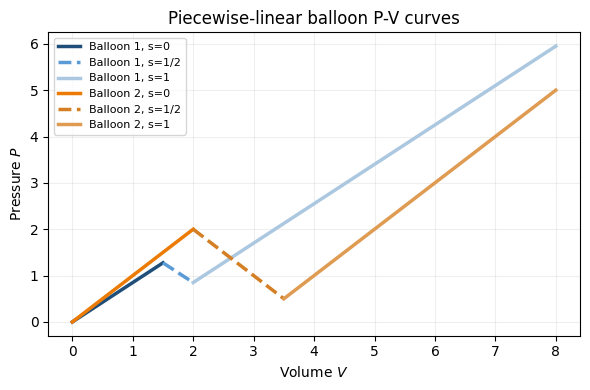

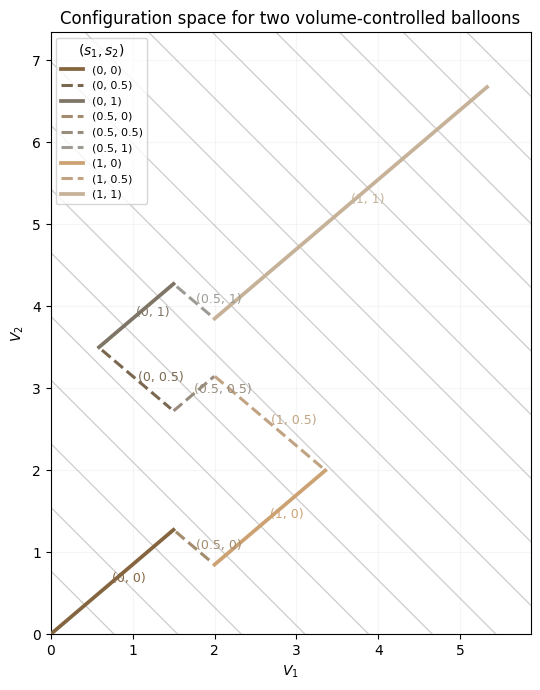

In [57]:
balloon2 = {
    "m": 1.0,
    "a": 2.0,
    "b": 3.5,
}

balloon1 = {
    "m": 0.85,
    "a": 1.5,
    "b": 2,
}

VT_values = np.linspace(0.0, 12.0, 2000)

branches = compute_configuration_space(balloon1, balloon2, VT_values)

plot_pressure_volume_curves(balloon1, balloon2, Vmax=8.0)
plot_configuration_space(branches)

# Piecewise linear, different slopes (2 balloons)

## Model

In [58]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Piecewise-linear balloon model from Sec. II.B
# s = 0   : first ascending branch
# s = 0.5 : descending branch
# s = 1   : second ascending branch
# ------------------------------------------------------------

def branch_params(p, s):
    """
    Return g, h for P(V) = g V + h.

    Each branch has its own slope:
        s = 0   : g0
        s = 0.5 : g_mid
        s = 1   : g1

    The intercepts are chosen so that the pressure-volume
    curve is continuous at V = a and V = b.
    """
    a = p["a"]
    b = p["b"]

    g0 = p["g0"]
    g_mid = p["g_mid"]
    g1 = p["g1"]

    if s == 0:
        g = g0
        h = 0.0

    elif s == 0.5:
        g = g_mid
        h = (g0 - g_mid) * a

    elif s == 1:
        g = g1
        h = (g0 - g_mid) * a + (g_mid - g1) * b

    else:
        raise ValueError("State must be 0, 0.5, or 1.")

    return g, h


def volume_range(a, b, s):
    """
    Valid volume interval for a branch.
    """
    if s == 0:
        return 0.0, a
    elif s == 0.5:
        return a, b
    elif s == 1:
        return b, np.inf
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def solve_two_balloon_state(VT, p1, p2, s1, s2):
    """
    Solve for V1, V2, P for a fixed total volume VT
    and fixed branch pair (s1, s2).

    Equations:
        P1(V1) = P2(V2)
        V1 + V2 = VT
    """
    g1, h1 = branch_params(p1, s1)
    g2, h2 = branch_params(p2, s2)

    denom = g1 + g2

    if abs(denom) < 1e-12:
        return None

    V1 = (g2 * VT + h2 - h1) / denom
    V2 = VT - V1
    P = g1 * V1 + h1

    return V1, V2, P

def is_valid_branch(V, a, b, s, tol=1e-9):
    """
    Check whether volume V lies inside the branch interval.
    """
    lo, hi = volume_range(a, b, s)

    if np.isinf(hi):
        return V >= lo - tol
    else:
        return (V >= lo - tol) and (V <= hi + tol)


def is_stable_state(s1, s2):
    """
    For the piecewise-linear N-shaped curve:
        ascending branches are stable
        descending branch s = 1/2 is unstable

    For visualization, mark a configuration stable only when both
    balloons are on ascending branches.
    """
    return (s1 != 0.5) and (s2 != 0.5)


def compute_configuration_space(p1, p2, VT_values):
    """
    Compute all valid configuration-space branches for two balloons.
    """
    states = [0, 0.5, 1]
    branches = {}

    for s1 in states:
        for s2 in states:
            key = (s1, s2)
            data = {
                "VT": [],
                "V1": [],
                "V2": [],
                "P": [],
                "stable": is_stable_state(s1, s2),
            }

            for VT in VT_values:
                sol = solve_two_balloon_state(VT, p1, p2, s1, s2)
                if sol is None:
                    continue

                V1, V2, P = sol

                ok1 = is_valid_branch(V1, p1["a"], p1["b"], s1)
                ok2 = is_valid_branch(V2, p2["a"], p2["b"], s2)

                if ok1 and ok2 and V1 >= 0 and V2 >= 0:
                    data["VT"].append(VT)
                    data["V1"].append(V1)
                    data["V2"].append(V2)
                    data["P"].append(P)

            branches[key] = data

    return branches



## Plotter

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Example parameters
# ------------------------------------------------------------
# a = volume at local pressure maximum
# b = volume at local pressure minimum
# m = absolute slope magnitude
#
# Changing a, b, m changes the topology / transition behavior.
# ------------------------------------------------------------

def get_branch_color(balloon_id, s):
    """
    Balloon 1: blue family
    Balloon 2: orange family

    s = 0   : darkest
    s = 0.5 : lighter
    s = 1   : lightest
    """
    colors = {
        1: {
            0:   "#1f4e79",  # dark blue
            0.5: "#5b9bd5",  # medium blue
            1:   "#acc8e0",  # light blue
        },
        2: {
            0:   "#eb7b04",  # dark orange
            0.5: "#d47f24",  # medium orange
            1:   "#df9b52",  # light orange
        },
    }

    return colors[balloon_id][s]


def hex_to_rgb01(hex_color):
    """
    Convert hex color to RGB in [0, 1].
    """
    hex_color = hex_color.lstrip("#")
    return np.array([
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    ]) / 255.0


def mixed_state_color(s1, s2, weight1=0.5):
    """
    Mix balloon 1 color for s1 and balloon 2 color for s2.
    """
    c1 = hex_to_rgb01(get_branch_color(1, s1))
    c2 = hex_to_rgb01(get_branch_color(2, s2))

    return weight1 * c1 + (1.0 - weight1) * c2


def plot_configuration_space(branches, VT_lines=True):
    """
    Plot V2 vs V1 configuration space.

    Branch color is determined by the pair of balloon states:
        color = mix(color_balloon1[s1], color_balloon2[s2])

    Solid = stable branch.
    Dashed = unstable branch.
    Gray diagonal lines = constant total volume V_T = V1 + V2.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    all_V1 = []
    all_V2 = []

    # Plot configuration-space branches
    for state, data in branches.items():
        s1, s2 = state

        V1 = np.array(data["V1"])
        V2 = np.array(data["V2"])

        if len(V1) < 2:
            continue

        all_V1.extend(V1)
        all_V2.extend(V2)

        color = mixed_state_color(s1, s2)

        if data["stable"]:
            linestyle = "-"
            linewidth = 2.7
        else:
            linestyle = "--"
            linewidth = 2.2

        ax.plot(
            V1,
            V2,
            linestyle=linestyle,
            linewidth=linewidth,
            color=color,
            label=f"{state}",
            zorder=3,
        )

        mid = len(V1) // 2
        ax.text(
            V1[mid],
            V2[mid],
            f"{state}",
            fontsize=9,
            color=color,
            zorder=4,
        )

    all_V1 = np.array(all_V1)
    all_V2 = np.array(all_V2)

    xmax = np.max(all_V1) * 1.10
    ymax = np.max(all_V2) * 1.10

    xmin = 0.0
    ymin = 0.0

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Constant total-volume lines: V1 + V2 = VT
    if VT_lines:
        VT_values = np.linspace(0.0, xmax + ymax, 18)

        for VT in VT_values:
            points = []

            # x = xmin
            x = xmin
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # x = xmax
            x = xmax
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # y = ymin
            y = ymin
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # y = ymax
            y = ymax
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # Remove duplicates
            unique_points = []
            for p in points:
                if p not in unique_points:
                    unique_points.append(p)

            if len(unique_points) >= 2:
                p0, p1 = unique_points[0], unique_points[1]

                ax.plot(
                    [p0[0], p1[0]],
                    [p0[1], p1[1]],
                    color="gray",
                    alpha=0.4,
                    linewidth=0.9,
                    zorder=1,
                )

    ax.set_xlabel(r"$V_1$")
    ax.set_ylabel(r"$V_2$")
    ax.set_title("Configuration space for two volume-controlled balloons")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.12, zorder=0)
    ax.legend(title=r"$(s_1,s_2)$", fontsize=8)
    plt.tight_layout()
    plt.show()



def plot_pressure_volume_curves(p1, p2, Vmax=8.0, n=500):
    """
    Plot individual piecewise-linear P-V curves with
    different slopes for each branch.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    for balloon_id, p, label in [
        (1, p1, "Balloon 1"),
        (2, p2, "Balloon 2"),
    ]:
        a = p["a"]
        b = p["b"]

        # Branch s = 0
        V0 = np.linspace(0, a, n)
        g, h = branch_params(p, 0)
        P0 = g * V0 + h

        # Branch s = 1/2
        Vh = np.linspace(a, b, n)
        g, h = branch_params(p, 0.5)
        Ph = g * Vh + h

        # Branch s = 1
        V1 = np.linspace(b, Vmax, n)
        g, h = branch_params(p, 1)
        P1 = g * V1 + h

        ax.plot(
            V0,
            P0,
            color=get_branch_color(balloon_id, 0),
            linewidth=2.5,
            label=f"{label}, s=0",
        )

        ax.plot(
            Vh,
            Ph,
            color=get_branch_color(balloon_id, 0.5),
            linewidth=2.5,
            linestyle="--",
            label=f"{label}, s=1/2",
        )

        ax.plot(
            V1,
            P1,
            color=get_branch_color(balloon_id, 1),
            linewidth=2.5,
            label=f"{label}, s=1",
        )

    ax.set_xlabel(r"Volume $V$")
    ax.set_ylabel(r"Pressure $P$")
    ax.set_title("Piecewise-linear balloon P-V curves")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Run: 2 balloon config space

In [ ]:
balloon1 = {
    "m": 0.85,
    "a": 1.5,
    "b": 2,
}

balloon2 = {
    "m": 1.0,
    "a": 2.0,
    "b": 3.5,
}



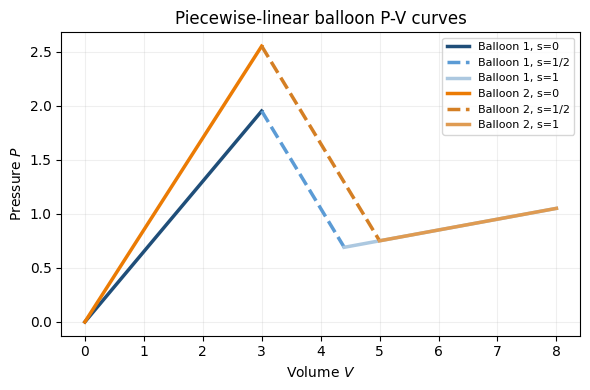

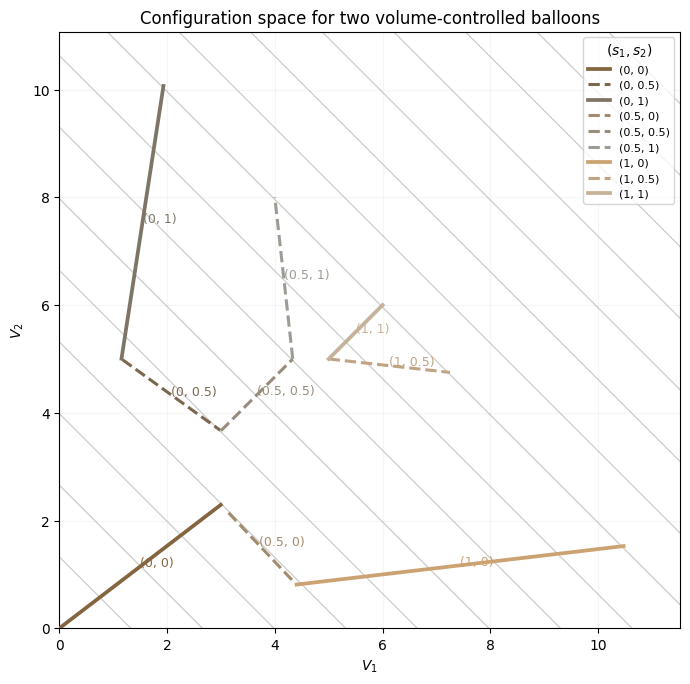

In [91]:
balloon1 = {
    "a": 3.0,
    "b": 4.4,
    "g0": 0.65,      # slope on first stable branch
    "g_mid": -0.9,  # slope on unstable branch
    "g1": 0.1,     # slope on second stable branch
}

balloon2 = {
    "a": 3,
    "b": 5,
    "g0": 0.85,
    "g_mid": -0.9,
    "g1": 0.1,
}


VT_values = np.linspace(0.0, 12.0, 2000)

branches = compute_configuration_space(balloon1, balloon2, VT_values)

plot_pressure_volume_curves(balloon1, balloon2, Vmax=8.0)
plot_configuration_space(branches)

# Fit Piecewise linear to bump to data

In [26]:
FOLDER = r"D:\\ucla_research\\Projects\\arduino_sketches\\arduinoPy\\sensor_logs\\pciPV\WHPeakCompare"

In [ ]:
import pandas as pd

def balloon_piecewise_linear_model_general(x, g0, g_mid, g1, a, b):
    """
    Piecewise-linear balloon instability model with different slopes
    on each branch.

    Branch 1:
        P(x) = g0 * x                         for x <= a

    Branch 2:
        P(x) = g_mid * x + h_mid              for a < x <= b

    Branch 3:
        P(x) = g1 * x + h1                    for x > b

    The intercepts are chosen so the curve is continuous at x = a and x = b.
    """

    x = np.asarray(x, dtype=float)

    # Continuity at x = a:
    # g0 * a = g_mid * a + h_mid
    h_mid = (g0 - g_mid) * a

    # Continuity at x = b:
    # g_mid * b + h_mid = g1 * b + h1
    h1 = (g_mid - g1) * b + h_mid

    y = np.empty_like(x, dtype=float)

    mask1 = x <= a
    mask2 = (x > a) & (x <= b)
    mask3 = x > b

    y[mask1] = g0 * x[mask1]
    y[mask2] = g_mid * x[mask2] + h_mid
    y[mask3] = g1 * x[mask3] + h1

    return y


def balloon_piecewise_linear_model_general_with_offset(
    x,
    g0,
    g_mid,
    g1,
    a,
    b,
    p0,
):
    """
    Same model with pressure offset p0.
    """

    return p0 + balloon_piecewise_linear_model_general(
        x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
    )


from scipy.optimize import least_squares

def fit_balloon_piecewise_linear_mass(
    df,
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    time_col="time normed (s)",
    t_min=6.0,
    use_offset=True,
):
    """
    Fit the generalized piecewise-linear balloon instability model.

    The model is:

        branch 0:      P = g0 x + p0
        branch 1/2:    P = g_mid x + h_mid + p0
        branch 1:      P = g1 x + h1 + p0

    with continuity enforced at x = a and x = b.

    Constraints:
        g0 > 0
        g_mid < 0
        g1 > 0
        a < b
    """

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
    valid &= t >= float(t_min)

    x = x[valid]
    y = y[valid]

    if x.size < 7:
        raise ValueError("Not enough valid data points to fit the generalized piecewise-linear model.")

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_min = float(np.min(x))
    x_max = float(np.max(x))
    x_range = x_max - x_min

    if x_range <= 0:
        raise ValueError("x data has zero range; cannot fit piecewise model.")

    # Initial breakpoint guesses
    a0 = x_min + 0.35 * x_range
    b0 = x_min + 0.70 * x_range

    # Estimate rough slope scale
    slope_scale = max(abs(np.max(y) - np.min(y)) / x_range, 1e-6)

    g0_0 = slope_scale
    g_mid_0 = -slope_scale
    g1_0 = slope_scale

    p00 = float(y[0] - balloon_piecewise_linear_model_general(
        x[0],
        g0=g0_0,
        g_mid=g_mid_0,
        g1=g1_0,
        a=a0,
        b=b0,
    ))

    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def logit(q):
        q = np.clip(q, 1e-6, 1.0 - 1e-6)
        return np.log(q / (1.0 - q))

    def unpack(theta):
        # Enforce:
        # g0 > 0
        # g_mid < 0
        # g1 > 0
        g0 = np.exp(theta[0])
        g_mid = -np.exp(theta[1])
        g1 = np.exp(theta[2])

        alpha = theta[3]
        beta = theta[4]

        a = x_min + sigmoid(alpha) * x_range
        b = a + sigmoid(beta) * (x_max - a)

        if use_offset:
            p0 = theta[5]
        else:
            p0 = 0.0

        return g0, g_mid, g1, a, b, p0

    def residual(theta):
        g0, g_mid, g1, a, b, p0 = unpack(theta)

        y_hat = balloon_piecewise_linear_model_general_with_offset(
            x,
            g0=g0,
            g_mid=g_mid,
            g1=g1,
            a=a,
            b=b,
            p0=p0,
        )

        return y_hat - y

    alpha0 = logit((a0 - x_min) / x_range)
    beta0 = logit((b0 - a0) / (x_max - a0))

    if use_offset:
        theta0 = np.array([
            np.log(g0_0),
            np.log(abs(g_mid_0)),
            np.log(g1_0),
            alpha0,
            beta0,
            p00,
        ])
    else:
        theta0 = np.array([
            np.log(g0_0),
            np.log(abs(g_mid_0)),
            np.log(g1_0),
            alpha0,
            beta0,
        ])

    opt = least_squares(
        residual,
        theta0,
        loss="soft_l1",
        max_nfev=20000,
    )

    g0, g_mid, g1, a, b, p0 = unpack(opt.x)

    y_pred = balloon_piecewise_linear_model_general_with_offset(
        x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
        p0=p0,
    )

    rmse = float(np.sqrt(np.mean((y_pred - y) ** 2)))

    h_mid = (g0 - g_mid) * a
    h1 = (g_mid - g1) * b + h_mid

    return {
        "params": {
            "g0": float(g0),
            "g_mid": float(g_mid),
            "g1": float(g1),
            "a": float(a),
            "b": float(b),
            "h_mid": float(h_mid),
            "h1": float(h1),
            "p0": float(p0),
        },
        "x_fit": x,
        "y_fit": y,
        "y_pred": y_pred,
        "rmse": rmse,
        "success": bool(opt.success),
        "message": opt.message,
    }

## Data load and process

In [ ]:
import glob
import re
from pathlib import Path

import pandas as pd


def add_mass_flow_and_cumulative_mass(
    df: pd.DataFrame,
    flow_col: str = "flow (slm)",
    time_col: str = "time (s)",
) -> pd.DataFrame:
    out = df.copy()

    # flow -> mass flow (kg/s) at 20 C
    out["mass flow (kg/s, 20C)"] = out[flow_col] * 0.0129 * 1.0732 * 1e-3 / 60.0

    # cumulative integral
    t = out[time_col].to_numpy(dtype=float)
    mdot = out["mass flow (kg/s, 20C)"].to_numpy(dtype=float)

    cum_mass = np.zeros_like(mdot, dtype=float)
    if len(mdot) > 1:
        dt = np.diff(t)
        interval_mass = 0.5 * (mdot[:-1] + mdot[1:]) * dt
        cum_mass[1:] = np.cumsum(interval_mass)

    out["cumulative mass (kg)"] = cum_mass
    return out




PATTERN_ALL_R = "pciPV-WHPeakCompare-0_P1Y{Y}W{W}H{H}T0N0xB_R*.csv"
PATTERN_ONE_R = "pciPV-WHPeakCompare-0_P1Y{Y}W{W}H{H}T0N0xB_R{R}.csv"


def find_files_all_R(folder: str, Y: int, W: int, H: int):
    pat = str(Path(folder) / PATTERN_ALL_R.format(Y=Y, W=W, H=H))
    return sorted(glob.glob(pat))


def find_file_one_R(folder: str, Y: int, W: int, H: int, R: int):
    return str(Path(folder) / PATTERN_ONE_R.format(Y=Y, W=W, H=H, R=R))


def _parse_R_from_path(pth: str):
    m = re.search(r"_R(\d+)\.csv$", str(pth))
    return int(m.group(1)) if m else None

def load_runs_by_H_single_W_as_dfs(
    folder: str,
    Y_values,
    W: int,
    H_values,
    runs_by_WH=None,   # {(W,H): "all" or [R,...]}
):
    """
    Load selected runs as SEPARATE DataFrames (no concatenation), keeping *all* CSV columns.

    Returns:
      dict mapping keys -> DataFrame

      key is a tuple: (Y, W, H, R)
      each DataFrame includes metadata columns:
        __folder, __Y, __W, __H, __R, __run_label, __path
    """
    W = int(W)
    runs_by_WH = runs_by_WH or {}
    folder_p = Path(folder)

    out = {}

    for Y in Y_values:
        Y = int(Y)
        for H in H_values:
            H = int(H)

            runs_spec = runs_by_WH.get((W, H), "all")
            if isinstance(runs_spec, str):
                if runs_spec.lower() != "all":
                    raise ValueError("runs_by_WH values must be 'all' or a list of ints.")
                runs_list = None
            else:
                runs_list = sorted({int(r) for r in runs_spec})

            if runs_list is None:
                paths = find_files_all_R(folder, Y=Y, W=W, H=H)
            else:
                paths = []
                for R in runs_list:
                    pth = find_file_one_R(folder, Y=Y, W=W, H=H, R=R)
                    if Path(pth).exists():
                        paths.append(pth)
                paths = sorted(paths)

            for pth in paths:
                df = pd.read_csv(pth)

                R = _parse_R_from_path(pth)
                run_label = f"Y{Y}_W{W}_H{H}_R{R}" if R is not None else f"Y{Y}_W{W}_H{H}"

                # metadata
                df["__folder"] = folder_p.name
                df["__Y"] = Y
                df["__W"] = W
                df["__H"] = H
                df["__R"] = R
                df["__run_label"] = run_label
                df["__path"] = str(Path(pth))

                out[(Y, W, H, R)] = df

    return out

## Plotter

In [43]:


def plot_all_runs_fitted_model_curves_from_loader_mass(
    folder: str,
    Y: int,
    W: int,
    H: int,
    runs_by_WH: dict,
    flow_col: str = "flow (slm)",
    time_col: str = "time normed (s)",
    x_col: str = "cumulative mass (kg)",
    p_col: str = "pressure (kPa)",
    fit_func=fit_balloon_piecewise_linear_mass,
    model_t_min: float = 6.0,
    n_line: int = 1600,
    ax=None,
    show_legend: bool = True,
    fit_kwargs=None,
    line_kwargs=None,
    show_raw: bool = True,          # NEW
    raw_alpha: float = 0.3,        # NEW
    raw_linewidth: float = 1.0,     # NEW
    raw_kwargs=None,                # NEW
):
    """
    Load runs internally, add cumulative-mass column, fit each run using the
    piecewise-linear balloon instability model, and plot only the fitted curves.

    x-axis is cumulative mass.
    """

    fit_kwargs = fit_kwargs or {}
    line_kwargs = line_kwargs or {}
    raw_kwargs = raw_kwargs or {}
    # baseline_kwargs = baseline_kwargs or {}

    dfs = load_runs_by_H_single_W_as_dfs(
        folder=folder,
        Y_values=[int(Y)],
        W=int(W),
        H_values=[int(H)],
        runs_by_WH=runs_by_WH,
    )

    run_keys = sorted(
        key for key in dfs.keys()
        if key[0] == int(Y) and key[1] == int(W) and key[2] == int(H)
    )

    if not run_keys:
        raise ValueError(f"No runs found for (Y={Y}, W={W}, H={H}).")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=200)

    results = {}

    for key in run_keys:
        _, _, _, R = key

        df = add_mass_flow_and_cumulative_mass(
            dfs[key],
            flow_col=flow_col,
            time_col=time_col,
        )
        dfs[key] = df

        res = fit_func(
            df,
            x_col=x_col,
            p_col=p_col,
            time_col=time_col,
            t_min=model_t_min,
            **fit_kwargs,
        )

        results[R] = res

        x_all = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
        y_all = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
        t_all = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(t_all)
        valid &= t_all >= float(model_t_min)

        x_valid = x_all[valid]

        if x_valid.size == 0:
            continue

        x_start = float(np.min(x_valid))
        x_end = float(np.max(x_valid))

        if x_end <= x_start:
            continue

        # x_start = float(res["x_fit_min"])
        # x_end = float(res["x_fit_max"])
        # if x_end <= x_start:
        #     continue

        xx = np.linspace(x_start, x_end, int(n_line))

        params = res["params"]


        yy = balloon_piecewise_linear_model_general_with_offset(
                xx,
                g0=params["g0"],
                g_mid=params["g_mid"],
                g1=params["g1"],
                a=params["a"],
                b=params["b"],
                p0=params["p0"],
                )

        fit_line, = ax.plot(
            xx,
            yy,
            label=f"R{R} fit, RMSE={res['rmse']:.3g}",
            **line_kwargs,
        )

        fit_color = fit_line.get_color()

        # Plot raw data in the SAME color with low opacity
        if show_raw:
            ax.plot(
                x_all,
                y_all,
                color=fit_color,
                alpha=raw_alpha,
                linewidth=raw_linewidth,
                label=f"R{R} raw" if show_legend else "_nolegend_",
                **raw_kwargs,
            )

        # Optional: show breakpoint locations
        # ax.axvline(params["a"], linestyle=":", alpha=0.25)
        # ax.axvline(params["b"], linestyle=":", alpha=0.25)

    ax.set_xlabel(x_col)
    ax.set_ylabel(p_col)
    ax.set_title(
        f"Piecewise-linear balloon model fits: Y={Y}, W={W}, H={H}"
    )
    ax.grid(True, alpha=0.3)

    if show_legend:
        ax.legend(fontsize=8)

    return ax, results, dfs

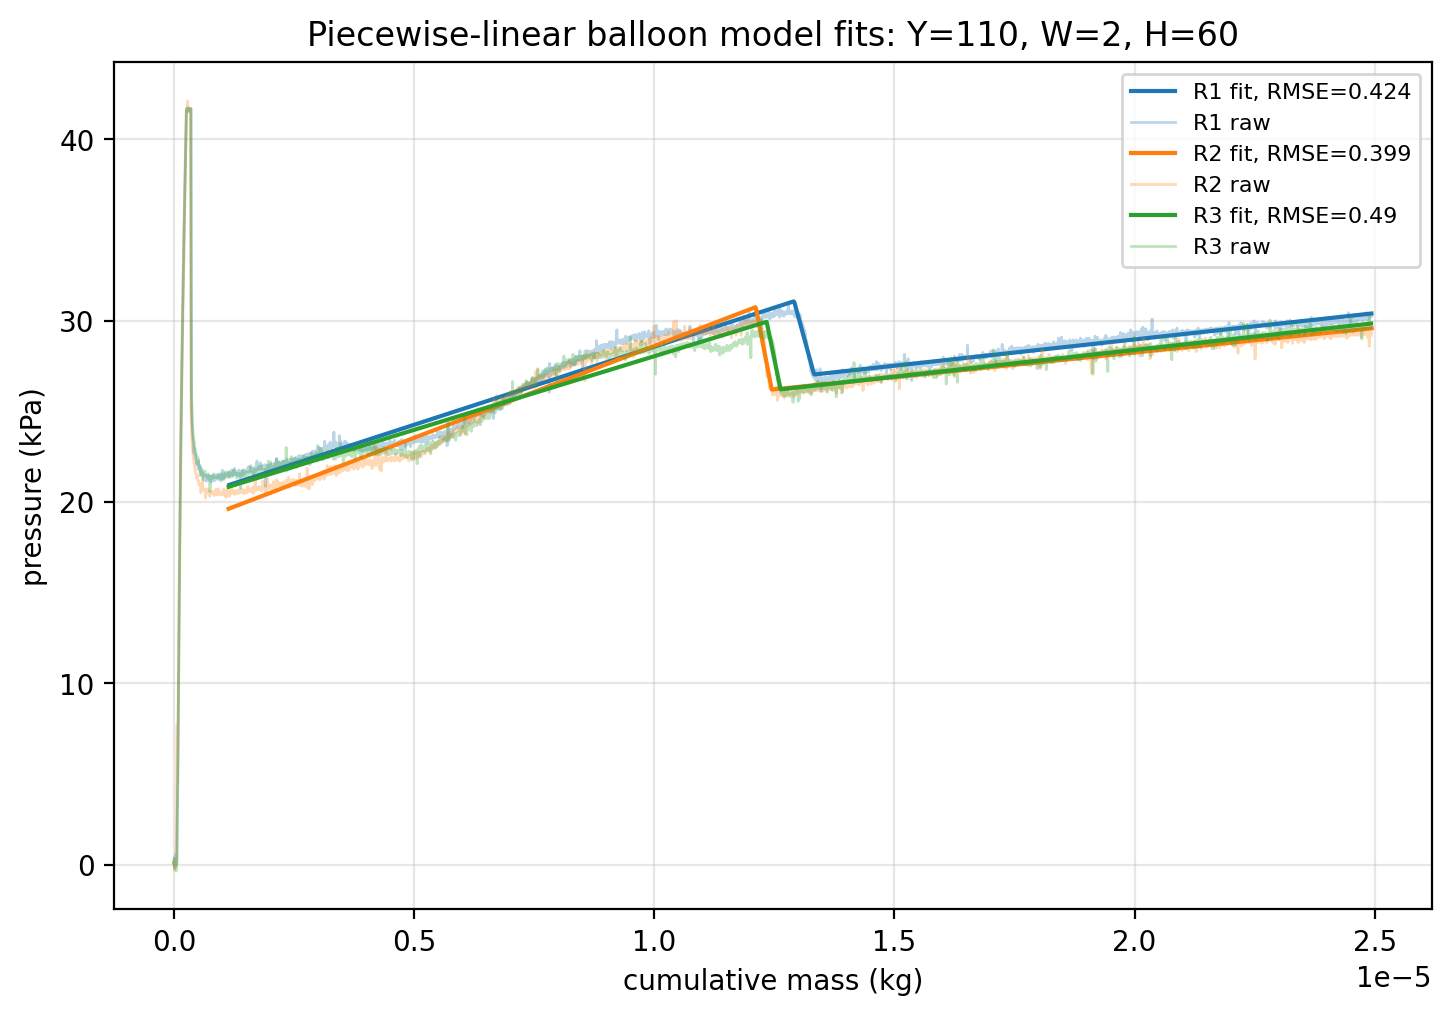

In [46]:
runs_by_WH = {
    (2, 40): [1, 2, 3],
    (4, 40): [1, 2, 3],
    (2, 60): [1, 2, 3],
    (4, 60): [2, 3, 4],
}

ax, results, dfs_loaded = plot_all_runs_fitted_model_curves_from_loader_mass(
    folder=FOLDER,
    Y=110,
    W=2,
    H=60,
    runs_by_WH=runs_by_WH,
    model_t_min=6.0,
    show_legend=True,
    fit_kwargs={
        "use_offset": True,
    },
    raw_alpha=0.3
)

plt.show()

In [60]:
for R, res in results.items():
    print(f"Run {R}")
    print(res["params"])
    print("RMSE:", res["rmse"])
    print()

Run 1
{'g0': 861340.2600513506, 'g_mid': -9701769.837667298, 'g1': 289763.5815456869, 'a': 1.2910493195995247e-05, 'b': 1.332690484951558e-05, 'h_mid': 136.3749610451453, 'h1': 3.218745866538825, 'p0': 19.949693873885966}
RMSE: 0.4239539773933039

Run 2
{'g0': 1013513.9246835541, 'g_mid': -13598030.35796965, 'g1': 270250.1435218719, 'a': 1.2111812442390315e-05, 'b': 1.2446081564990235e-05, 'h_mid': 176.97228384517615, 'h1': 4.366533557449003, 'p0': 18.469479509605552}
RMSE: 0.39899814733686906

Run 3
{'g0': 812508.7786553276, 'g_mid': -12835975.161602996, 'g1': 295237.4971014597, 'a': 1.233902054738751e-05, 'b': 1.2629627795313e-05, 'h_mid': 168.4089237795359, 'h1': 2.5665953989962134, 'p0': 19.913512270912424}
RMSE: 0.4897465373125928



# Fit and Save. Load saved then plot

## Model fit and save

In [92]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [93]:
def balloon_piecewise_linear_model_general(x, g0, g_mid, g1, a, b):
    """
    Piecewise-linear balloon instability model with different slopes.

    Branch 0:
        P = g0 * x

    Branch 1/2:
        P = g_mid * x + h_mid

    Branch 1:
        P = g1 * x + h1

    h_mid and h1 are chosen so the curve is continuous at a and b.
    """

    x = np.asarray(x, dtype=float)

    h_mid = (g0 - g_mid) * a
    h1 = (g_mid - g1) * b + h_mid

    y = np.empty_like(x, dtype=float)

    mask0 = x <= a
    mask_mid = (x > a) & (x <= b)
    mask1 = x > b

    y[mask0] = g0 * x[mask0]
    y[mask_mid] = g_mid * x[mask_mid] + h_mid
    y[mask1] = g1 * x[mask1] + h1

    return y


def balloon_piecewise_linear_model_general_with_offset(
    x,
    g0,
    g_mid,
    g1,
    a,
    b,
    p0=0.0,
):
    return p0 + balloon_piecewise_linear_model_general(
        x=x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
    )

In [94]:
def fit_balloon_piecewise_linear_mass(
    df,
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    time_col="time normed (s)",
    t_min=6.0,
    use_offset=True,
):
    """
    Fit generalized piecewise-linear model.

    Fitted parameters:
        a, b, g0, g_mid, g1

    Optional:
        p0
    """

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
    valid &= t >= float(t_min)

    x = x[valid]
    y = y[valid]

    if x.size < 7:
        raise ValueError("Not enough valid data points to fit model.")

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_min = float(np.min(x))
    x_max = float(np.max(x))
    x_range = x_max - x_min

    if x_range <= 0:
        raise ValueError("x data has zero range.")

    a0 = x_min + 0.35 * x_range
    b0 = x_min + 0.70 * x_range

    slope_scale = max(abs(np.max(y) - np.min(y)) / x_range, 1e-9)

    g0_0 = slope_scale
    g_mid_0 = -slope_scale
    g1_0 = slope_scale

    p0_0 = float(
        y[0]
        - balloon_piecewise_linear_model_general(
            x[0],
            g0=g0_0,
            g_mid=g_mid_0,
            g1=g1_0,
            a=a0,
            b=b0,
        )
    )

    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def logit(q):
        q = np.clip(q, 1e-6, 1.0 - 1e-6)
        return np.log(q / (1.0 - q))

    def unpack(theta):
        # Enforce signs:
        # g0 > 0, g_mid < 0, g1 > 0
        g0 = np.exp(theta[0])
        g_mid = -np.exp(theta[1])
        g1 = np.exp(theta[2])

        alpha = theta[3]
        beta = theta[4]

        a = x_min + sigmoid(alpha) * x_range
        b = a + sigmoid(beta) * (x_max - a)

        if use_offset:
            p0 = theta[5]
        else:
            p0 = 0.0

        return g0, g_mid, g1, a, b, p0

    def residual(theta):
        g0, g_mid, g1, a, b, p0 = unpack(theta)

        y_hat = balloon_piecewise_linear_model_general_with_offset(
            x,
            g0=g0,
            g_mid=g_mid,
            g1=g1,
            a=a,
            b=b,
            p0=p0,
        )

        return y_hat - y

    alpha0 = logit((a0 - x_min) / x_range)
    beta0 = logit((b0 - a0) / (x_max - a0))

    if use_offset:
        theta0 = np.array(
            [
                np.log(g0_0),
                np.log(abs(g_mid_0)),
                np.log(g1_0),
                alpha0,
                beta0,
                p0_0,
            ],
            dtype=float,
        )
    else:
        theta0 = np.array(
            [
                np.log(g0_0),
                np.log(abs(g_mid_0)),
                np.log(g1_0),
                alpha0,
                beta0,
            ],
            dtype=float,
        )

    opt = least_squares(
        residual,
        theta0,
        loss="soft_l1",
        max_nfev=20000,
    )

    g0, g_mid, g1, a, b, p0 = unpack(opt.x)

    y_pred = balloon_piecewise_linear_model_general_with_offset(
        x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
        p0=p0,
    )

    rmse = float(np.sqrt(np.mean((y_pred - y) ** 2)))

    h_mid = (g0 - g_mid) * a
    h1 = (g_mid - g1) * b + h_mid

    return {
        "params": {
            "a": float(a),
            "b": float(b),
            "g0": float(g0),
            "g_mid": float(g_mid),
            "g1": float(g1),
            "h_mid": float(h_mid),
            "h1": float(h1),
            "p0": float(p0),
        },
        "rmse": rmse,
        "success": bool(opt.success),
        "message": str(opt.message),
    }

In [95]:
def fit_runs_by_WH_and_save_piecewise_json(
    folder,
    Y,
    runs_by_WH,
    json_save_path,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    model_t_min=6.0,
    use_offset=True,
):
    """
    Fit all runs specified by runs_by_WH and save model parameters to JSON.

    runs_by_WH format:
        {
            (W, H): [R1, R2, R3],
            ...
        }

    Each JSON entry contains:
        csv_path
        Y, W, H, R
        a, b, g0, g_mid, g1
        p0, rmse
    """

    entries = []

    for (W, H), R_list in runs_by_WH.items():

        dfs = load_runs_by_H_single_W_as_dfs(
            folder=folder,
            Y_values=[int(Y)],
            W=int(W),
            H_values=[int(H)],
            runs_by_WH={(int(W), int(H)): R_list},
        )

        run_keys = sorted(dfs.keys())

        if len(run_keys) == 0:
            print(f"No files found for Y={Y}, W={W}, H={H}, runs={R_list}")
            continue

        for key in run_keys:
            Y_key, W_key, H_key, R_key = key
            df = dfs[key]

            csv_path = str(df["__path"].iloc[0])

            df = add_mass_flow_and_cumulative_mass(
                df,
                flow_col=flow_col,
                time_col=time_col,
            )

            try:
                res = fit_balloon_piecewise_linear_mass(
                    df,
                    x_col=x_col,
                    p_col=p_col,
                    time_col=time_col,
                    t_min=model_t_min,
                    use_offset=use_offset,
                )

                params = res["params"]

                entry = {
                    "csv_path": csv_path,
                    "Y": int(Y_key),
                    "W": int(W_key),
                    "H": int(H_key),
                    "R": int(R_key),

                    "a": float(params["a"]),
                    "b": float(params["b"]),
                    "g0": float(params["g0"]),
                    "g_mid": float(params["g_mid"]),
                    "g1": float(params["g1"]),

                    "h_mid": float(params["h_mid"]),
                    "h1": float(params["h1"]),
                    "p0": float(params["p0"]),

                    "rmse": float(res["rmse"]),
                    "success": bool(res["success"]),
                    "message": str(res["message"]),

                    "x_col": x_col,
                    "p_col": p_col,
                    "time_col": time_col,
                    "flow_col": flow_col,
                    "model_t_min": float(model_t_min),
                }

            except Exception as e:
                entry = {
                    "csv_path": csv_path,
                    "Y": int(Y_key),
                    "W": int(W_key),
                    "H": int(H_key),
                    "R": int(R_key),

                    "a": None,
                    "b": None,
                    "g0": None,
                    "g_mid": None,
                    "g1": None,

                    "h_mid": None,
                    "h1": None,
                    "p0": None,

                    "rmse": None,
                    "success": False,
                    "message": str(e),

                    "x_col": x_col,
                    "p_col": p_col,
                    "time_col": time_col,
                    "flow_col": flow_col,
                    "model_t_min": float(model_t_min),
                }

            entries.append(entry)

            if entry["success"]:
                print(
                    f"Fitted Y={Y_key}, W={W_key}, H={H_key}, R={R_key}: "
                    f"a={entry['a']:.4g}, b={entry['b']:.4g}, "
                    f"g0={entry['g0']:.4g}, g_mid={entry['g_mid']:.4g}, "
                    f"g1={entry['g1']:.4g}, rmse={entry['rmse']:.4g}"
                )
            else:
                print(
                    f"Failed Y={Y_key}, W={W_key}, H={H_key}, R={R_key}: "
                    f"{entry['message']}"
                )

    output = {
        "model": "general_piecewise_linear_balloon",
        "description": "P(x) is piecewise linear with slopes g0, g_mid, g1 and continuous breakpoints a, b.",
        "entries": entries,
    }

    with open(json_save_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"\nSaved fitted parameters to:\n{json_save_path}")

    return output

In [96]:
runs_by_WH = {
    (2, 40): [1, 2, 3],
    (4, 40): [1, 2, 3],
    (2, 60): [1, 2, 3],
    (4, 60): [2, 3, 4],
}

fit_results_json = fit_runs_by_WH_and_save_piecewise_json(
    folder=FOLDER,
    Y=110,
    runs_by_WH=runs_by_WH,
    json_save_path="piecewise_balloon_fit_params_Y110.json",
    model_t_min=6.0,
    use_offset=True,
)

Fitted Y=110, W=2, H=40, R=1: a=9.024e-06, b=9.117e-06, g0=1.293e+06, g_mid=-5.397e+07, g1=3.175e+05, rmse=0.436
Fitted Y=110, W=2, H=40, R=2: a=1.059e-05, b=1.347e-05, g0=8.809e+05, g_mid=-7.614e+05, g1=2.71e+05, rmse=0.4303
Fitted Y=110, W=2, H=40, R=3: a=1.205e-05, b=1.228e-05, g0=8.578e+05, g_mid=-1.492e+07, g1=2.591e+05, rmse=0.4707
Fitted Y=110, W=4, H=40, R=1: a=1.249e-05, b=1.256e-05, g0=1.11e+06, g_mid=-1.029e+08, g1=3.286e+05, rmse=0.6332
Fitted Y=110, W=4, H=40, R=2: a=1.256e-05, b=1.261e-05, g0=1.114e+06, g_mid=-1.174e+08, g1=3.12e+05, rmse=0.7192
Fitted Y=110, W=4, H=40, R=3: a=8.748e-06, b=8.748e-06, g0=7.952e+05, g_mid=-1.945e-05, g1=1.164e+05, rmse=1.576
Fitted Y=110, W=2, H=60, R=1: a=1.291e-05, b=1.333e-05, g0=8.613e+05, g_mid=-9.702e+06, g1=2.898e+05, rmse=0.424
Fitted Y=110, W=2, H=60, R=2: a=1.211e-05, b=1.245e-05, g0=1.014e+06, g_mid=-1.36e+07, g1=2.703e+05, rmse=0.399
Fitted Y=110, W=2, H=60, R=3: a=1.234e-05, b=1.263e-05, g0=8.125e+05, g_mid=-1.284e+07, g1=2.952

## Plotter

In [112]:
def plot_piecewise_fits_from_json(
    json_path,
    Y,
    runs_by_WH,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    model_t_min=None,
    n_line=1600,
    ax=None,
    plot_raw=True,
    raw_alpha=0.3,
    raw_linewidth=1.0,
    show_breakpoints=True,
    show_legend=True,
    fit_line_kwargs=None,
    raw_kwargs=None,
):
    """
    Plot saved piecewise-linear fits from JSON.

    runs_by_WH format:
        {
            (W, H): [R1, R2, R3],
            ...
        }

    If plot_raw=True, raw data from the saved CSV path is plotted too.
    """

    fit_line_kwargs = fit_line_kwargs or {}
    raw_kwargs = raw_kwargs or {}

    with open(json_path, "r") as f:
        data = json.load(f)

    entries = data["entries"]

    entry_lookup = {}
    for e in entries:
        key = (int(e["Y"]), int(e["W"]), int(e["H"]), int(e["R"]))
        entry_lookup[key] = e

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=200)

    for (W, H), R_list in runs_by_WH.items():
        for R in R_list:

            key = (int(Y), int(W), int(H), int(R))

            if key not in entry_lookup:
                print(f"Skipping missing entry: Y={Y}, W={W}, H={H}, R={R}")
                continue

            entry = entry_lookup[key]

            if not entry.get("success", False):
                print(f"Skipping failed fit: Y={Y}, W={W}, H={H}, R={R}")
                continue

            csv_path = entry["csv_path"]
            df = pd.read_csv(csv_path)

            df = add_mass_flow_and_cumulative_mass(
                df,
                flow_col=flow_col,
                time_col=time_col,
            )

            x_all = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
            y_all = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
            t_all = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

            if model_t_min is None:
                t_min_use = float(entry.get("model_t_min", 0.0))
            else:
                t_min_use = float(model_t_min)

            valid = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(t_all)
            valid &= t_all >= t_min_use

            x_valid = x_all[valid]
            y_valid = y_all[valid]

            if x_valid.size == 0:
                print(f"No valid data for Y={Y}, W={W}, H={H}, R={R}")
                continue

            x_start = float(np.min(x_valid))
            x_end = float(np.max(x_valid))

            if x_end <= x_start:
                continue

            # choose a shared color for raw + fit
            xx = np.linspace(x_start, x_end, int(n_line))

            yy = balloon_piecewise_linear_model_general_with_offset(
                xx,
                g0=float(entry["g0"]),
                g_mid=float(entry["g_mid"]),
                g1=float(entry["g1"]),
                a=float(entry["a"]),
                b=float(entry["b"]),
                p0=float(entry.get("p0", 0.0)),
            )

            # Plot fitted model first
            fit_line, = ax.plot(
                xx,
                yy,
                label=f"Y{Y} W{W} H{H} R{R} fit",
                **fit_line_kwargs,
            )

            fit_color = fit_line.get_color()

            # Plot raw data using same color, lower opacity
            if plot_raw:
                ax.plot(
                    x_all,
                    y_all,
                    color=fit_color,
                    alpha=raw_alpha,
                    linewidth=raw_linewidth,
                    label=f"Y{Y} W{W} H{H} R{R} raw" if show_legend else "_nolegend_",
                    **raw_kwargs,
                )

            if show_breakpoints:
                ax.axvline(float(entry["a"]), linestyle=":", alpha=0.20)
                ax.axvline(float(entry["b"]), linestyle=":", alpha=0.20)

    ax.set_xlabel(x_col)
    ax.set_ylabel(p_col)
    ax.set_title(f"Piecewise-linear balloon fits from JSON: Y={Y}")
    ax.grid(True, alpha=0.3)

    if show_legend:
        ax.legend(fontsize=8)

    return ax

## Run

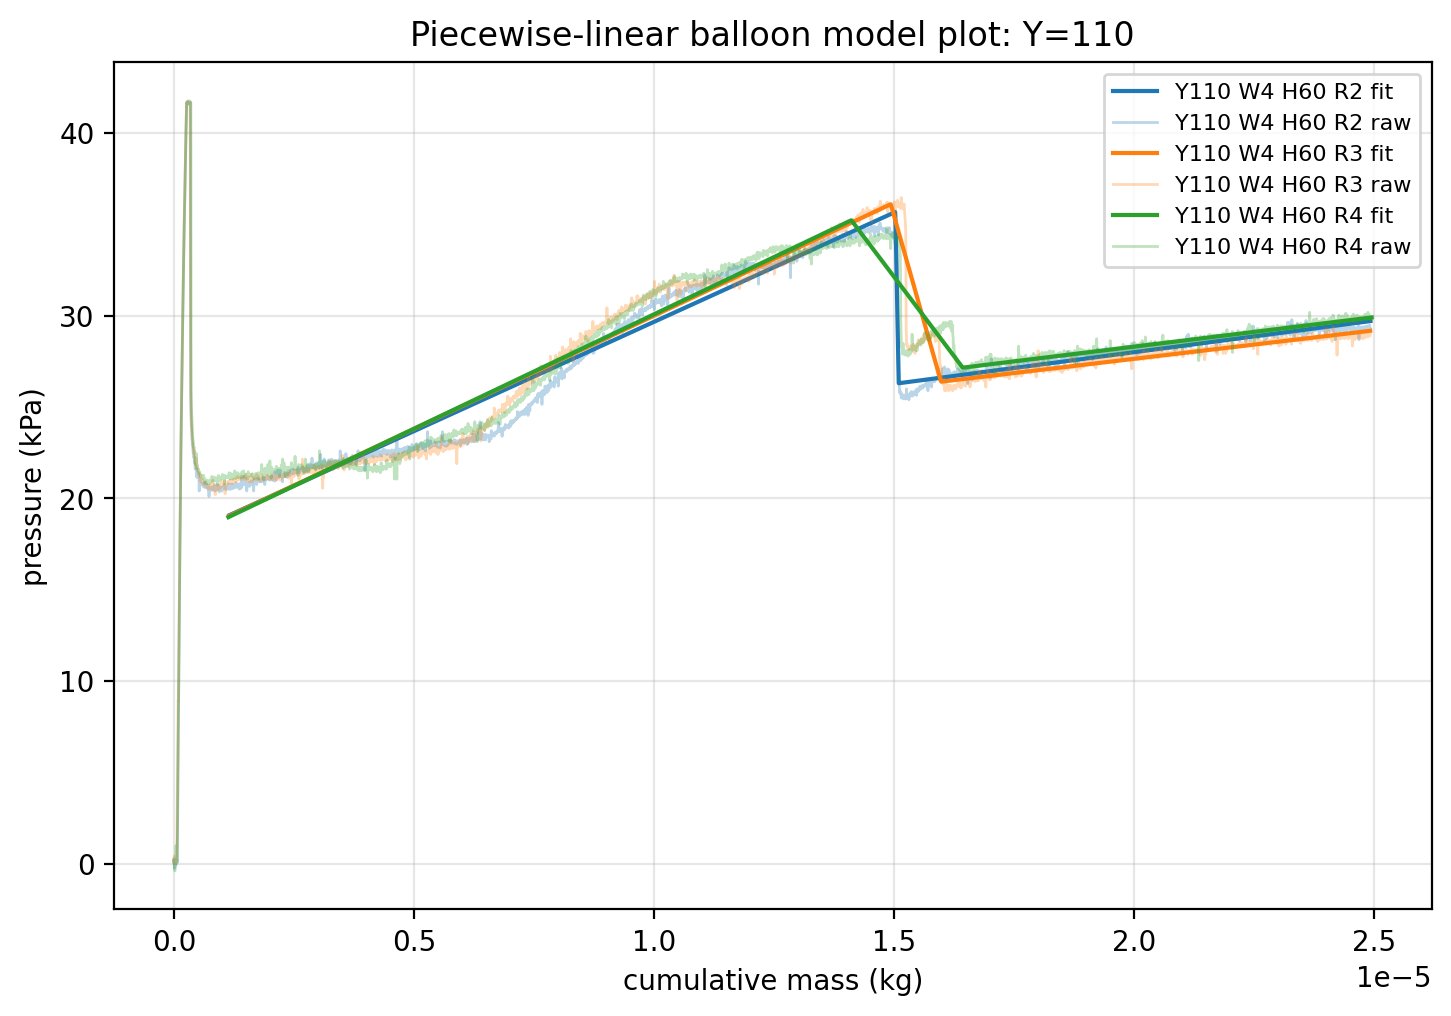

In [144]:
runs_to_plot = {
    (4, 60): [2, 3 , 4],
}

ax = plot_piecewise_fits_from_json(
    json_path="piecewise_balloon_fit_params_Y110.json",
    Y=110,
    runs_by_WH=runs_to_plot,
    plot_raw=True,
    model_t_min=6.0,
    raw_alpha=0.3,
    raw_linewidth=1.0,
    show_breakpoints=False
)

# ax = None
plt.show()

## Avg of piecewise linear models

In [135]:
from pathlib import Path
import json
import numpy as np

def make_average_piecewise_model_json(
    input_json_path,
    output_json_path,
    Y,
    W,
    H,
    runs="all",
    average_p0=True,
):
    """
    Average fitted piecewise-linear balloon models for one (Y, W, H).

    The averaging is done as:

        a_avg     = mean(a_i)
        b_avg     = mean(b_i)
        g0_avg    = mean(g0_i)
        g_mid_avg = mean(g_mid_i)
        g1_avg    = mean(g1_i)

    Optionally:

        p0_avg = mean(p0_i)

    Then h_mid and h1 are recomputed so the averaged model is continuous.
    """

    with open(input_json_path, "r") as f:
        data = json.load(f)

    entries = data["entries"]

    Y = int(Y)
    W = int(W)
    H = int(H)

    if isinstance(runs, str):
        if runs.lower() != "all":
            raise ValueError("runs must be 'all' or a list of integers.")
        runs_use = None
    else:
        runs_use = sorted({int(r) for r in runs})

    selected = []

    for e in entries:
        if not e.get("success", False):
            continue

        if int(e["Y"]) != Y:
            continue
        if int(e["W"]) != W:
            continue
        if int(e["H"]) != H:
            continue

        R = int(e["R"])

        if runs_use is not None and R not in runs_use:
            continue

        required = ["a", "b", "g0", "g_mid", "g1"]

        if average_p0:
            required.append("p0")

        if any(e.get(k, None) is None for k in required):
            continue

        selected.append(e)

    if len(selected) == 0:
        raise ValueError(
            f"No successful fitted models found for Y={Y}, W={W}, H={H}, runs={runs}."
        )

    selected = sorted(selected, key=lambda e: int(e["R"]))

    # ------------------------------------------------------------
    # Average the actual model parameters
    # ------------------------------------------------------------

    a_avg = float(np.mean([float(e["a"]) for e in selected]))
    b_avg = float(np.mean([float(e["b"]) for e in selected]))
    print([float(e["b"]) for e in selected])

    g0_avg = float(np.mean([float(e["g0"]) for e in selected]))
    g_mid_avg = float(np.mean([float(e["g_mid"]) for e in selected]))
    print([float(e["g_mid"]) for e in selected])
    print("gmid",g_mid_avg)
    g1_avg = float(np.mean([float(e["g1"]) for e in selected]))

    if average_p0:
        p0_avg = float(np.mean([float(e.get("p0", 0.0)) for e in selected]))
    else:
        p0_avg = 0.0

    # ------------------------------------------------------------
    # Recompute intercepts from averaged values
    # Do NOT average h_mid or h1 directly.
    # ------------------------------------------------------------

    h_mid_avg = float((g0_avg - g_mid_avg) * a_avg)
    h1_avg = float((g_mid_avg - g1_avg) * b_avg + h_mid_avg)

    averaged_runs = [int(e["R"]) for e in selected]
    csv_paths = [e["csv_path"] for e in selected]

    folder_names = sorted({Path(p).parent.name for p in csv_paths})

    if len(folder_names) == 1:
        folder_name = folder_names[0]
    else:
        folder_name = "__".join(folder_names)

    runs_key = "_".join([f"R{r}" for r in averaged_runs])

    dict_key = (
        f"folder={folder_name}"
        f"__Y{Y}_W{W}_H{H}"
        f"__runs={runs_key}"
    )

    avg_entry = {
        "folder_name": folder_name,
        "Y": Y,
        "W": W,
        "H": H,

        "averaged_runs": averaged_runs,
        "num_averaged_runs": len(averaged_runs),
        "source_csv_paths": csv_paths,

        # averaged breakpoints
        "a": a_avg,
        "b": b_avg,

        # averaged slopes
        "g0": g0_avg,
        "g_mid": g_mid_avg,
        "g1": g1_avg,

        # averaged offset
        "p0": p0_avg,

        # recomputed continuity intercepts
        "h_mid": h_mid_avg,
        "h1": h1_avg,

        "source_fit_json": str(input_json_path),
        "averaging_method": "mean_of_a_b_and_branch_slopes",
        "note": "h_mid and h1 are recomputed from averaged a, b, g0, g_mid, and g1, not averaged directly.",
    }

    output = {
        "model": "average_general_piecewise_linear_balloon",
        "description": (
            "Average model computed by averaging the branch slopes g0, g_mid, g1 "
            "and the transition points a, b across selected fitted models."
        ),
        "entries": {
            dict_key: avg_entry
        },
    }

    with open(output_json_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"Saved averaged model to:\n{output_json_path}")
    print(f"Averaged entry key:\n{dict_key}")

    return output

In [160]:
def make_average_piecewise_model_json(
    input_json_path,
    output_json_path,
    Y,
    W,
    H,
    runs="all",
    average_p0=True,
):
    """
    Average fitted piecewise-linear balloon models for one (Y, W, H).

    Averaging rule:
        a_avg  = mean(a_i)
        b_avg  = mean(b_i)
        g0_avg = mean(g0_i)
        g1_avg = mean(g1_i)

    But g_mid is NOT averaged directly.

    Instead:
        P_a_avg = mean pressure at a_i
        P_b_avg = mean pressure at b_i

        g_mid_avg = (P_b_avg - P_a_avg) / (b_avg - a_avg)

    Then h_mid and h1 are recomputed so the averaged model is continuous.
    """

    with open(input_json_path, "r") as f:
        data = json.load(f)

    entries = data["entries"]

    Y = int(Y)
    W = int(W)
    H = int(H)

    if isinstance(runs, str):
        if runs.lower() != "all":
            raise ValueError("runs must be 'all' or a list of integers.")
        runs_use = None
    else:
        runs_use = sorted({int(r) for r in runs})

    selected = []

    for e in entries:
        if not e.get("success", False):
            continue

        if int(e["Y"]) != Y:
            continue
        if int(e["W"]) != W:
            continue
        if int(e["H"]) != H:
            continue

        R = int(e["R"])

        if runs_use is not None and R not in runs_use:
            continue

        required = ["a", "b", "g0", "g_mid", "g1"]

        if average_p0:
            required.append("p0")

        if any(e.get(k, None) is None for k in required):
            continue

        selected.append(e)

    if len(selected) == 0:
        raise ValueError(
            f"No successful fitted models found for Y={Y}, W={W}, H={H}, runs={runs}."
        )

    selected = sorted(selected, key=lambda e: int(e["R"]))

    # ------------------------------------------------------------
    # Average transition points and stable-branch slopes
    # ------------------------------------------------------------

    a_avg = float(np.mean([float(e["a"]) for e in selected]))
    b_avg = float(np.mean([float(e["b"]) for e in selected]))

    g0_avg = float(np.mean([float(e["g0"]) for e in selected]))
    g1_avg = float(np.mean([float(e["g1"]) for e in selected]))

    if average_p0:
        p0_avg = float(np.mean([float(e.get("p0", 0.0)) for e in selected]))
    else:
        p0_avg = 0.0

    if b_avg <= a_avg:
        raise ValueError(
            f"Invalid averaged breakpoints: a_avg={a_avg}, b_avg={b_avg}. Need b_avg > a_avg."
        )

    # ------------------------------------------------------------
    # Compute average pressure at each model's own a_i and b_i
    # ------------------------------------------------------------
    # For each fitted model:
    #
    #   P(a_i) = p0_i + g0_i * a_i
    #
    #   P(b_i) = p0_i + g_mid_i * b_i + h_mid_i
    #
    # where:
    #
    #   h_mid_i = (g0_i - g_mid_i) * a_i
    #
    # Equivalently:
    #
    #   P(b_i) = p0_i + g0_i*a_i + g_mid_i*(b_i - a_i)
    #
    # Then the averaged middle slope connects:
    #
    #   (a_avg, P_a_avg) to (b_avg, P_b_avg)
    # ------------------------------------------------------------

    P_a_values = []
    P_b_values = []

    for e in selected:
        a_i = float(e["a"])
        b_i = float(e["b"])
        g0_i = float(e["g0"])
        g_mid_i = float(e["g_mid"])
        p0_i = float(e.get("p0", 0.0)) if average_p0 else 0.0

        P_a_i = p0_i + g0_i * a_i
        P_b_i = p0_i + g0_i * a_i + g_mid_i * (b_i - a_i)

        P_a_values.append(P_a_i)
        P_b_values.append(P_b_i)

    P_a_avg = float(np.mean(P_a_values))
    P_b_avg = float(np.mean(P_b_values))

    # ------------------------------------------------------------
    # Do NOT average g_mid.
    # Get it from the line connecting averaged endpoint pressures.
    # ------------------------------------------------------------

    g_mid_avg = float((P_b_avg - P_a_avg) / (b_avg - a_avg))

    # ------------------------------------------------------------
    # Recompute p0 so branch 0 passes through (a_avg, P_a_avg)
    # ------------------------------------------------------------
    #
    # branch 0:
    #   P = p0 + g0_avg * x
    #
    # require:
    #   P_a_avg = p0_avg_corrected + g0_avg * a_avg
    #
    # so:
    #   p0_avg_corrected = P_a_avg - g0_avg * a_avg
    #
    # This is better than directly using mean(p0_i), because it forces
    # the averaged curve to pass through the averaged endpoint pressure.
    # ------------------------------------------------------------

    p0_avg_corrected = float(P_a_avg - g0_avg * a_avg)

    if not average_p0:
        p0_avg_corrected = 0.0

    # ------------------------------------------------------------
    # Recompute continuity intercepts from averaged values
    # ------------------------------------------------------------

    h_mid_avg = float((g0_avg - g_mid_avg) * a_avg)
    h1_avg = float((g_mid_avg - g1_avg) * b_avg + h_mid_avg)

    averaged_runs = [int(e["R"]) for e in selected]
    csv_paths = [e["csv_path"] for e in selected]

    folder_names = sorted({Path(p).parent.name for p in csv_paths})

    if len(folder_names) == 1:
        folder_name = folder_names[0]
    else:
        folder_name = "__".join(folder_names)

    runs_key = "_".join([f"R{r}" for r in averaged_runs])

    dict_key = (
        f"folder={folder_name}"
        f"__Y{Y}_W{W}_H{H}"
        f"__runs={runs_key}"
    )

    avg_entry = {
        "folder_name": folder_name,
        "Y": Y,
        "W": W,
        "H": H,

        "averaged_runs": averaged_runs,
        "num_averaged_runs": len(averaged_runs),
        "source_csv_paths": csv_paths,

        # averaged breakpoints
        "a": a_avg,
        "b": b_avg,

        # averaged stable branch slopes
        "g0": g0_avg,
        "g1": g1_avg,

        # middle slope computed from averaged endpoint connection
        "g_mid": g_mid_avg,

        # endpoint pressures used to compute g_mid
        "P_a_avg": P_a_avg,
        "P_b_avg": P_b_avg,

        # corrected offset
        "p0": p0_avg_corrected,

        # recomputed continuity intercepts
        "h_mid": h_mid_avg,
        "h1": h1_avg,

        "source_fit_json": str(input_json_path),
        "averaging_method": "mean_a_b_g0_g1_and_mid_slope_from_averaged_endpoint_pressures",
        "note": (
            "g_mid is not averaged directly. It is computed as "
            "(P_b_avg - P_a_avg) / (b_avg - a_avg), where P_a_avg and P_b_avg "
            "are the mean pressures at each fit model's own a_i and b_i."
        ),
    }

    # ------------------------------------------------------------
    # Append/update this averaged model inside the same JSON file
    # instead of overwriting all previous averaged models.
    # ------------------------------------------------------------

    if Path(output_json_path).exists():
        with open(output_json_path, "r") as f:
            output = json.load(f)

        if "entries" not in output:
            output["entries"] = {}

        if not isinstance(output["entries"], dict):
            raise ValueError(
                "Existing averaged-model JSON has invalid format: "
                "'entries' must be a dictionary."
            )

    else:
        output = {
            "model": "average_general_piecewise_linear_balloon",
            "description": (
                "Average models computed by averaging a, b, g0, and g1, while computing "
                "g_mid from the line connecting the averaged endpoint pressures."
            ),
            "entries": {},
        }

    # Add or update only this averaged model entry
    output["entries"][dict_key] = avg_entry

    with open(output_json_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"Saved averaged model to:\n{output_json_path}")
    print(f"Averaged entry key:\n{dict_key}")
    print(f"Computed g_mid from endpoint line: {g_mid_avg:.6g}")

    return output

In [138]:
runs_by_WH

{(2, 40): [1, 2, 3],
 (4, 40): [1, 2, 3],
 (2, 60): [1, 2, 3],
 (4, 60): [2, 3, 4]}

In [176]:
avg_json = make_average_piecewise_model_json(
    input_json_path="piecewise_balloon_fit_params_Y110.json",
    output_json_path="average_piecewise_balloon_fit_params_Y110.json",
    Y=110,
    W=2,
    H=40,
    runs=[1, 2, 3],
)

Saved averaged model to:
average_piecewise_balloon_fit_params_Y110.json
Averaged entry key:
folder=WHPeakCompare__Y110_W2_H40__runs=R1_R2_R3
Computed g_mid from endpoint line: -3.33344e+06


In [ ]:


def _load_piecewise_entries_any_json(json_path):
    """
    Supports both JSON formats:

    1. Individual fit JSON:
        {"entries": [{...}, {...}]}

    2. Averaged model JSON:
        {"entries": {"model_key": {...}}}
    """

    with open(json_path, "r") as f:
        data = json.load(f)

    entries = data["entries"]

    if isinstance(entries, list):
        return entries

    if isinstance(entries, dict):
        out = []
        for model_key, entry in entries.items():
            entry = dict(entry)
            entry["model_key"] = model_key
            out.append(entry)
        return out

    raise ValueError("Unsupported JSON format.")

def _read_xy_from_csv(
    csv_path,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
):
    """
    Read one CSV, add cumulative mass, and return x, y, t arrays.
    """

    df = pd.read_csv(csv_path)

    df = add_mass_flow_and_cumulative_mass(
        df,
        flow_col=flow_col,
        time_col=time_col,
    )

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    return x, y, t

def _get_valid_x_domain_from_paths(
    csv_paths,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    t_min=0.0,
):
    """
    Get x-domain from one or more CSV files after applying t >= t_min.
    """

    x_valid_all = []

    for csv_path in csv_paths:
        x, y, t = _read_xy_from_csv(
            csv_path,
            flow_col=flow_col,
            time_col=time_col,
            x_col=x_col,
            p_col=p_col,
        )

        valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
        valid &= t >= float(t_min)

        if np.any(valid):
            x_valid_all.append(x[valid])

    if len(x_valid_all) == 0:
        return None, None

    x_valid_all = np.concatenate(x_valid_all)

    x_start = float(np.min(x_valid_all))
    x_end = float(np.max(x_valid_all))

    if x_end <= x_start:
        return None, None

    return x_start, x_end


def _plot_raw_paths(
    ax,
    csv_paths,
    color,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    raw_alpha=0.3,
    raw_linewidth=1.0,
    raw_label=None,
    raw_kwargs=None,
):
    """
    Plot raw data from one or more CSV paths.
    """

    raw_kwargs = raw_kwargs or {}

    for i, csv_path in enumerate(csv_paths):
        x, y, _ = _read_xy_from_csv(
            csv_path,
            flow_col=flow_col,
            time_col=time_col,
            x_col=x_col,
            p_col=p_col,
        )

        label = raw_label if i == 0 else "_nolegend_"

        ax.plot(
            x,
            y,
            color=color,
            alpha=raw_alpha,
            linewidth=raw_linewidth,
            label=label,
            **raw_kwargs,
        )


def _plot_one_piecewise_entry(
    ax,
    entry,
    csv_paths,
    label,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    model_t_min=None,
    n_line=1600,
    plot_raw=True,
    raw_alpha=0.3,
    raw_linewidth=1.0,
    show_breakpoints=True,
    show_legend=True,
    fit_line_kwargs=None,
    raw_kwargs=None,
):
    """
    Plot one fitted or averaged piecewise model entry.
    """

    fit_line_kwargs = fit_line_kwargs or {}
    raw_kwargs = raw_kwargs or {}

    if model_t_min is None:
        t_min_use = float(entry.get("model_t_min", 0.0))
    else:
        t_min_use = float(model_t_min)

    x_start, x_end = _get_valid_x_domain_from_paths(
        csv_paths,
        flow_col=flow_col,
        time_col=time_col,
        x_col=x_col,
        p_col=p_col,
        t_min=t_min_use,
    )

    if x_start is None or x_end is None:
        print(f"No valid x-domain for {label}")
        return

    xx = np.linspace(x_start, x_end, int(n_line))

    yy = balloon_piecewise_linear_model_general_with_offset(
        xx,
        g0=float(entry["g0"]),
        g_mid=float(entry["g_mid"]),
        g1=float(entry["g1"]),
        a=float(entry["a"]),
        b=float(entry["b"]),
        p0=float(entry.get("p0", 0.0)),
    )

    fit_line, = ax.plot(
        xx,
        yy,
        label=label,
        **fit_line_kwargs,
    )

    fit_color = fit_line.get_color()

    if plot_raw:
        raw_label = label.replace("fit", "raw") if "fit" in label else "_nolegend_"

        _plot_raw_paths(
            ax,
            csv_paths,
            color=fit_color,
            flow_col=flow_col,
            time_col=time_col,
            x_col=x_col,
            p_col=p_col,
            raw_alpha=raw_alpha,
            raw_linewidth=raw_linewidth,
            raw_label=raw_label if show_legend else "_nolegend_",
            raw_kwargs=raw_kwargs,
        )

    if show_breakpoints:
        ax.axvline(
            float(entry["a"]),
            linestyle=":",
            color=fit_color,
            alpha=0.20,
        )
        ax.axvline(
            float(entry["b"]),
            linestyle=":",
            color=fit_color,
            alpha=0.20,
        )


def plot_piecewise_fits_from_json(
    json_path,
    Y,
    runs_by_WH=None,
    averaged_model_keys=None,
    flow_col="flow (slm)",
    time_col="time normed (s)",
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    model_t_min=None,
    n_line=1600,
    ax=None,
    plot_raw=True,
    raw_alpha=0.3,
    raw_linewidth=1.0,
    show_breakpoints=True,
    show_legend=True,
    fit_line_kwargs=None,
    raw_kwargs=None,
):
    """
    Compact plotter for either:

    1. Individual fitted models:
        runs_by_WH={(4, 60): [2, 3, 4]}

    2. Averaged models:
        runs_by_WH=None
    """

    fit_line_kwargs = fit_line_kwargs or {}
    raw_kwargs = raw_kwargs or {}

    entries = _load_piecewise_entries_any_json(json_path)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=200)

    Y = int(Y)

    # ------------------------------------------------------------
    # Case 1: individual model JSON
    # ------------------------------------------------------------
    if runs_by_WH is not None:

        entry_lookup = {
            (int(e["Y"]), int(e["W"]), int(e["H"]), int(e["R"])): e
            for e in entries
            if "R" in e and e.get("success", True)
        }

        for (W, H), R_list in runs_by_WH.items():
            for R in R_list:

                key = (Y, int(W), int(H), int(R))

                if key not in entry_lookup:
                    print(f"Skipping missing entry: Y={Y}, W={W}, H={H}, R={R}")
                    continue

                entry = entry_lookup[key]
                csv_path = entry.get("csv_path", None)

                if csv_path is None:
                    print(f"No csv_path for Y={Y}, W={W}, H={H}, R={R}")
                    continue

                label = f"Y{Y} W{W} H{H} R{R} fit"

                _plot_one_piecewise_entry(
                    ax=ax,
                    entry=entry,
                    csv_paths=[csv_path],
                    label=label,
                    flow_col=flow_col,
                    time_col=time_col,
                    x_col=x_col,
                    p_col=p_col,
                    model_t_min=model_t_min,
                    n_line=n_line,
                    plot_raw=plot_raw,
                    raw_alpha=raw_alpha,
                    raw_linewidth=raw_linewidth,
                    show_breakpoints=show_breakpoints,
                    show_legend=show_legend,
                    fit_line_kwargs=fit_line_kwargs,
                    raw_kwargs=raw_kwargs,
                )

    # ------------------------------------------------------------
    # Case 2: averaged model JSON
    # ------------------------------------------------------------
    else:

        for entry in entries:

            if int(entry["Y"]) != Y:
                continue

            model_key = entry.get("model_key", None)

            if averaged_model_keys is not None and model_key not in averaged_model_keys:
                continue

            csv_paths = entry.get("source_csv_paths", [])

            if len(csv_paths) == 0:
                print(f"No source_csv_paths for averaged model: {model_key}")
                continue

            W = int(entry["W"])
            H = int(entry["H"])

            averaged_runs = entry.get("averaged_runs", [])
            runs_label = "_".join([f"R{r}" for r in averaged_runs])

            label = f"AVG Y{Y} W{W} H{H} {runs_label}"

            _plot_one_piecewise_entry(
                ax=ax,
                entry=entry,
                csv_paths=csv_paths,
                label=label,
                flow_col=flow_col,
                time_col=time_col,
                x_col=x_col,
                p_col=p_col,
                model_t_min=model_t_min,
                n_line=n_line,
                plot_raw=plot_raw,
                raw_alpha=raw_alpha,
                raw_linewidth=raw_linewidth,
                show_breakpoints=show_breakpoints,
                show_legend=show_legend,
                fit_line_kwargs=fit_line_kwargs,
                raw_kwargs=raw_kwargs,
            )

    ax.set_xlabel(x_col)
    ax.set_ylabel(p_col)
    ax.set_title(f"Piecewise-linear balloon model plot: Y={Y}")
    ax.grid(True, alpha=0.3)

    if show_legend:
        ax.legend(fontsize=8)

    return ax



## Run

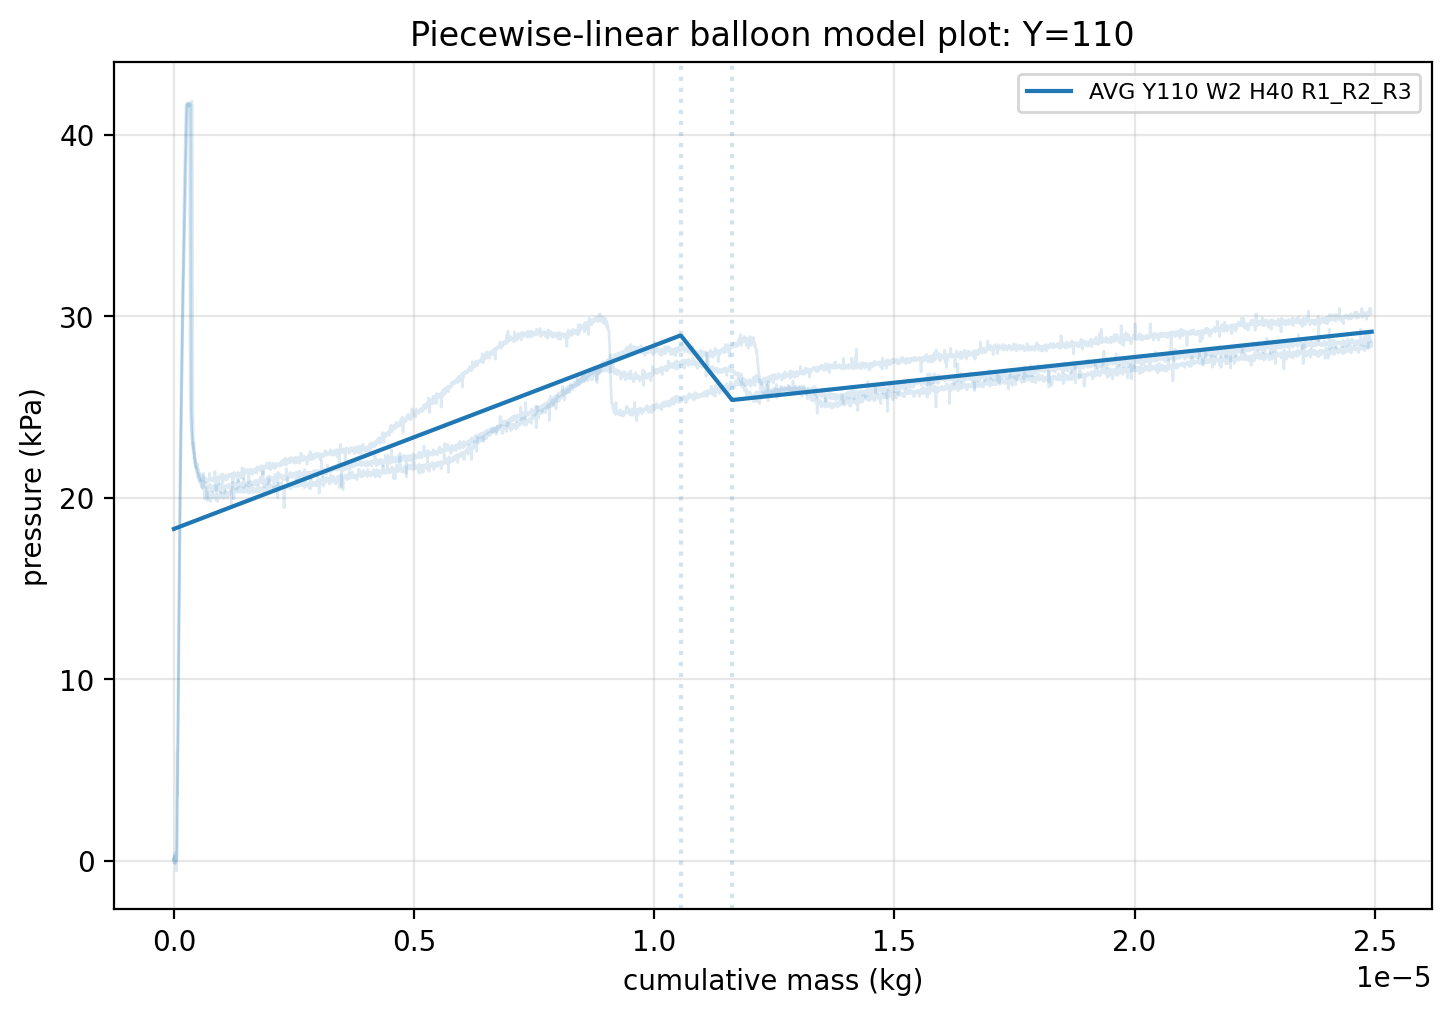

In [177]:
ax = plot_piecewise_fits_from_json(
    json_path="average_piecewise_balloon_fit_params_Y110.json",
    Y=110,
    runs_by_WH=None,
    averaged_model_keys=[
        # "folder=WHPeakCompare__Y110_W4_H60__runs=R2_R3_R4"
        # "folder=WHPeakCompare__Y110_W4_H40__runs=R1_R2"
        # "folder=WHPeakCompare__Y110_W2_H60__runs=R1_R2_R3"
        "folder=WHPeakCompare__Y110_W2_H40__runs=R1_R2_R3"
    ],
    plot_raw=True,
    raw_alpha=0.15,
    raw_linewidth=1.0,
)

plt.show()

# Configuration Space: 1 patch each

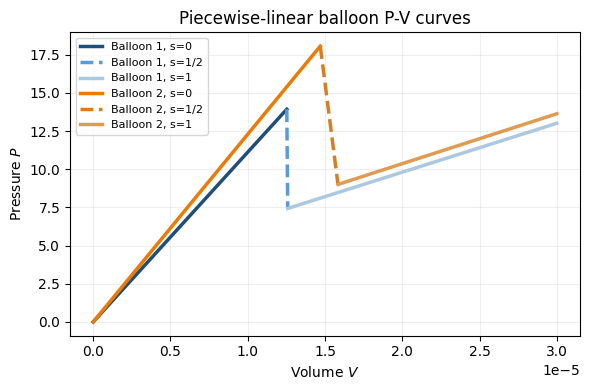

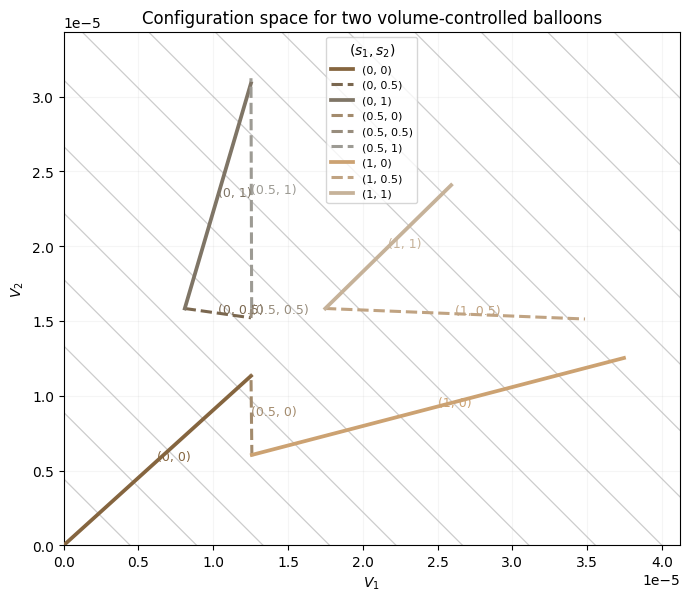

In [172]:
balloon1 = {
    "a": 1.2526931124065331e-05,
    "b": 1.2586167335709663e-05,
    "g0": 1111967.799539518,
    "g1": 320303.99278270523,
    "g_mid": -109677263.80782348,
}

balloon2 = {
    "a": 1.4693289747690504e-05,
    "b": 1.5839186175789234e-05,
    "g0": 1229359.6536422845,
    "g1": 326867.4757450167,
    "g_mid": -7904707.672843353,
}

n = 10000
VT_values = np.linspace(0.0, 5e-5, n )

branches = compute_configuration_space(balloon1, balloon2, VT_values)

plot_pressure_volume_curves(balloon1, balloon2, Vmax=3e-5, n = n)
plot_configuration_space(branches)

# Configuration Space multiple patches 

In [181]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def lighten_color(color, amount):
    """
    Lighten a color by mixing it with white.

    amount = 0.0 -> original color
    amount = 1.0 -> white
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1.0 - amount) * rgb + amount * white)


def get_instability_base_color(instability_index):
    """
    Base colors for p1, p2, p3, ...
    Repeats if there are more instabilities than colors.
    """
    base_colors = [
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#2ca02c",  # green
        "#d62728",  # red
        "#9467bd",  # purple
        "#8c564b",  # brown
        "#17becf",  # cyan
    ]

    return base_colors[(instability_index - 1) % len(base_colors)]


def get_instability_branch_color(instability_key, s):
    """
    Each instability gets one base color.

    s = 0   : darkest
    s = 0.5 : slightly lighter
    s = 1   : lightest, but still visible
    """
    instability_index = int(instability_key[1:])  # "p1" -> 1
    base = get_instability_base_color(instability_index)

    if s == 0:
        return lighten_color(base, 0.00)
    elif s == 0.5:
        return lighten_color(base, 0.28)
    elif s == 1:
        return lighten_color(base, 0.52)
    else:
        raise ValueError("State must be 0, 0.5, or 1.")

In [182]:
import numpy as np
import matplotlib.pyplot as plt


def branch_params_single_instability(instability, s):
    """
    Return local g, h for one instability model.

    Local model:
        P(V) = g V_local + h_local

    where V_local = V - V_start.

    Each instability has:
        a      : local volume where pressure reaches local max
        b      : local volume where pressure reaches local min
        g0     : slope of s = 0 branch
        g_mid  : slope of s = 0.5 branch
        g1     : slope of s = 1 branch
    """
    a = instability["a"]
    b = instability["b"]

    g0 = instability["g0"]
    g_mid = instability["g_mid"]
    g1 = instability["g1"]

    if s == 0:
        g = g0
        h = 0.0

    elif s == 0.5:
        g = g_mid
        h = (g0 - g_mid) * a

    elif s == 1:
        g = g1
        h = (g0 - g_mid) * a + (g_mid - g1) * b

    else:
        raise ValueError("State must be 0, 0.5, or 1.")

    return g, h


def get_sorted_instability_keys(balloon):
    """
    Sort keys like p1, p2, p3, ...
    """
    return sorted(balloon.keys(), key=lambda k: int(k[1:]))


def preprocess_multi_instability_balloon(balloon):
    """
    Add global start/end volume and pressure offsets to each instability.

    Each instability dictionary should contain:
        a
        b
        g0
        g_mid
        g1
        next_start

    Here next_start is the GLOBAL volume where the next instability begins.
    For the final instability, next_start can be None.

    This function assumes:
        p1 starts at V = 0
        p2 starts at p1["next_start"]
        p3 starts at p2["next_start"]
        etc.

    It also makes the full pressure-volume curve continuous by computing
    the pressure offset at the start of each instability.
    """
    keys = get_sorted_instability_keys(balloon)

    V_start = 0.0
    P_start = 0.0

    processed = {}

    for i, key in enumerate(keys):
        inst = balloon[key].copy()

        inst["V_start"] = V_start
        inst["P_start"] = P_start

        next_start = inst.get("next_start", None)

        if next_start is None:
            inst["V_end"] = np.inf
        else:
            inst["V_end"] = next_start

        processed[key] = inst

        # Compute pressure at the end of this instability.
        # This sets the offset for the next instability.
        if next_start is not None:
            P_start = pressure_multi_instability_at_volume(
                next_start,
                processed,
                already_processed=True,
            )
            V_start = next_start

    return processed


def pressure_single_instability_global(V, instability, s):
    """
    Pressure on a given branch of one instability in global coordinates.

    Local pressure:
        P_local = g * V_local + h

    Global pressure:
        P_global = P_start + P_local

    where:
        V_local = V - V_start
    """
    V_local = V - instability["V_start"]

    g, h = branch_params_single_instability(instability, s)

    P = instability["P_start"] + g * V_local + h

    return P


def local_branch_volume_range(instability, s):
    """
    Local valid range for a branch.
    """
    a = instability["a"]
    b = instability["b"]

    if s == 0:
        return 0.0, a

    elif s == 0.5:
        return a, b

    elif s == 1:
        return b, np.inf

    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def is_valid_multi_state(V, instability, s, tol=1e-9):
    """
    Check whether global volume V lies on branch s of this instability.

    Must satisfy:
        1. V is inside the global volume window of this instability.
        2. local volume lies inside the branch range.
    """
    V_start = instability["V_start"]
    V_end = instability["V_end"]

    if not (V >= V_start - tol and V <= V_end + tol):
        return False

    V_local = V - V_start
    lo, hi = local_branch_volume_range(instability, s)

    if np.isinf(hi):
        return V_local >= lo - tol
    else:
        return (V_local >= lo - tol) and (V_local <= hi + tol)


def pressure_multi_instability_at_volume(V, balloon, already_processed=False):
    """
    Evaluate the observable pressure P(V) for the multi-instability balloon.

    This follows the main connected path:
        p1_0 -> p1_0.5 -> p1_1 -> p2_0 -> p2_0.5 -> p2_1 -> ...

    If balloon is not already processed, preprocess it first.
    """
    if not already_processed:
        balloon = preprocess_multi_instability_balloon(balloon)

    keys = get_sorted_instability_keys(balloon)

    for key in keys:
        inst = balloon[key]
        V_start = inst["V_start"]
        V_end = inst["V_end"]

        if V >= V_start and V <= V_end:
            V_local = V - V_start

            if V_local <= inst["a"]:
                s = 0
            elif V_local <= inst["b"]:
                s = 0.5
            else:
                s = 1

            return pressure_single_instability_global(V, inst, s)

    # If V exceeds all finite windows, use the final instability
    key = keys[-1]
    inst = balloon[key]
    return pressure_single_instability_global(V, inst, 1)


def get_multi_instability_state_at_volume(V, balloon):
    """
    Return the prefixed state label at a given volume.

    Example:
        p1_0
        p1_0.5
        p1_1
        p2_0
        ...
    """
    balloon = preprocess_multi_instability_balloon(balloon)
    keys = get_sorted_instability_keys(balloon)

    for key in keys:
        inst = balloon[key]

        if V >= inst["V_start"] and V <= inst["V_end"]:
            V_local = V - inst["V_start"]

            if V_local <= inst["a"]:
                return f"{key}_0"
            elif V_local <= inst["b"]:
                return f"{key}_0.5"
            else:
                return f"{key}_1"

    return f"{keys[-1]}_1"


def get_all_multi_instability_branches(balloon):
    """
    Return all possible prefixed branches.

    Example:
        [
            ("p1", 0),
            ("p1", 0.5),
            ("p1", 1),
            ("p2", 0),
            ...
        ]
    """
    balloon = preprocess_multi_instability_balloon(balloon)
    keys = get_sorted_instability_keys(balloon)

    branches = []

    for key in keys:
        branches.append((key, 0))
        branches.append((key, 0.5))
        branches.append((key, 1))

    return branches


def branch_params_multi_instability(balloon, prefixed_state):
    """
    Return global g, h for a prefixed state.

    Input example:
        prefixed_state = ("p1", 0)
        prefixed_state = ("p2", 0.5)

    The global branch is:
        P(V) = g V + h_global

    Internally:
        P(V) = P_start + g (V - V_start) + h_local
             = g V + (P_start + h_local - g V_start)
    """
    balloon = preprocess_multi_instability_balloon(balloon)

    key, s = prefixed_state
    inst = balloon[key]

    g, h_local = branch_params_single_instability(inst, s)

    h_global = inst["P_start"] + h_local - g * inst["V_start"]

    return g, h_global


def plot_multi_instability_balloon(balloon, Vmax=None, n=1500):
    """
    Plot the full multi-instability pressure-volume curve.

    Each instability p1, p2, p3, ... has its own base color.
    Within each instability:
        s = 0   darkest
        s = 0.5 medium
        s = 1   lightest but still visible
    """
    balloon = preprocess_multi_instability_balloon(balloon)

    keys = get_sorted_instability_keys(balloon)

    if Vmax is None:
        finite_ends = [
            balloon[k]["V_end"]
            for k in keys
            if not np.isinf(balloon[k]["V_end"])
        ]

        if len(finite_ends) == 0:
            Vmax = balloon[keys[-1]]["V_start"] + balloon[keys[-1]]["b"] * 1.5
        else:
            Vmax = max(finite_ends) + balloon[keys[-1]]["b"] * 1.2

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for key in keys:
        inst = balloon[key]

        V_start = inst["V_start"]
        V_end = min(inst["V_end"], Vmax)

        if V_start >= Vmax:
            continue

        branch_specs = [
            # state, local min, local max, linestyle
            (0,   0.0,       inst["a"], "-"),
            (0.5, inst["a"], inst["b"], "--"),
            (1,   inst["b"], V_end - V_start, "-"),
        ]

        for s, lo_local, hi_local, linestyle in branch_specs:
            lo_global = V_start + lo_local
            hi_global = V_start + hi_local

            lo_global = max(lo_global, V_start)
            hi_global = min(hi_global, V_end)

            if hi_global <= lo_global:
                continue

            V = np.linspace(lo_global, hi_global, n)
            P = np.array([
                pressure_single_instability_global(v, inst, s)
                for v in V
            ])

            color = get_instability_branch_color(key, s)

            ax.plot(
                V,
                P,
                linestyle=linestyle,
                linewidth=2.7,
                color=color,
                label=f"{key}_{s}",
            )

        # Mark where the next instability starts
        if not np.isinf(inst["V_end"]):
            ax.axvline(
                inst["V_end"],
                color="gray",
                alpha=0.25,
                linewidth=1.0,
            )

            ax.text(
                inst["V_end"],
                ax.get_ylim()[0],
                f"{key} → next",
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=8,
                color="gray",
            )

    ax.set_xlabel("Volume V")
    ax.set_ylabel("Pressure P")
    ax.set_title("Balloon with multiple sequential instabilities")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    plt.show()

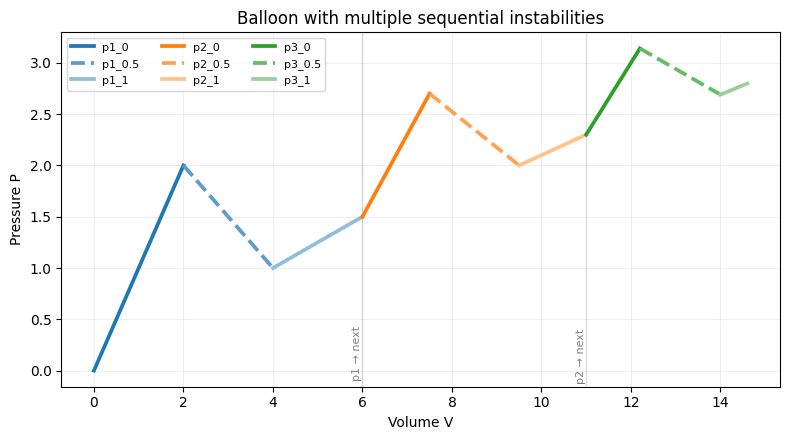

In [183]:
balloon_multi = {
    "p1": {
        "a": 2.0,
        "b": 4.0,
        "g0": 1.0,
        "g_mid": -0.5,
        "g1": 0.25,
        "next_start": 6.0,
    },

    "p2": {
        "a": 1.5,
        "b": 3.5,
        "g0": 0.8,
        "g_mid": -0.35,
        "g1": 0.20,
        "next_start": 11.0,
    },

    "p3": {
        "a": 1.2,
        "b": 3.0,
        "g0": 0.7,
        "g_mid": -0.25,
        "g1": 0.18,
        "next_start": None,
    },
}
plot_multi_instability_balloon(balloon_multi)

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ------------------------------------------------------------
# Helpers for colors
# ------------------------------------------------------------

def lighten_color(color, amount):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1.0 - amount) * rgb + amount * white)


def get_balloon_instability_base_color(balloon_id, instability_key):
    """
    Give each balloon its own color family.
    Within that family, each instability gets a related base color.
    """
    idx = int(instability_key[1:]) - 1  # p1 -> 0, p2 -> 1, ...

    if balloon_id == 1:
        base_colors = [
            "#1f77b4",  # blue
            "#2ca02c",  # green
            "#17becf",  # cyan
            "#9467bd",  # purple
        ]
    elif balloon_id == 2:
        base_colors = [
            "#ff7f0e",  # orange
            "#d62728",  # red
            "#8c564b",  # brown
            "#e377c2",  # pink
        ]
    else:
        raise ValueError("balloon_id must be 1 or 2.")

    return base_colors[idx % len(base_colors)]


def get_balloon_instability_branch_color(balloon_id, instability_key, s):
    """
    Same instability = same base color.
    s = 0   darkest
    s = 0.5 medium
    s = 1   lightest but visible
    """
    base = get_balloon_instability_base_color(balloon_id, instability_key)

    if s == 0:
        return lighten_color(base, 0.00)
    elif s == 0.5:
        return lighten_color(base, 0.28)
    elif s == 1:
        return lighten_color(base, 0.50)
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def mix_colors(c1, c2, w=0.5):
    c1 = np.array(mcolors.to_rgb(c1))
    c2 = np.array(mcolors.to_rgb(c2))
    return tuple(w * c1 + (1.0 - w) * c2)


# ------------------------------------------------------------
# Multi-instability branch utilities
# ------------------------------------------------------------

def get_all_prefixed_states(balloon):
    """
    Return all states for one multi-instability balloon.

    Example:
        [("p1", 0), ("p1", 0.5), ("p1", 1),
         ("p2", 0), ("p2", 0.5), ("p2", 1)]
    """
    balloon = preprocess_multi_instability_balloon(balloon)
    keys = get_sorted_instability_keys(balloon)

    states = []
    for key in keys:
        states.append((key, 0))
        states.append((key, 0.5))
        states.append((key, 1))

    return states


def get_global_branch_volume_range(balloon, prefixed_state):
    """
    Return the valid GLOBAL volume interval for a prefixed branch.

    prefixed_state = ("p2", 0.5), etc.
    """
    balloon = preprocess_multi_instability_balloon(balloon)

    key, s = prefixed_state
    inst = balloon[key]

    V_start = inst["V_start"]
    V_end = inst["V_end"]

    a = inst["a"]
    b = inst["b"]

    if s == 0:
        lo = V_start
        hi = V_start + a

    elif s == 0.5:
        lo = V_start + a
        hi = V_start + b

    elif s == 1:
        lo = V_start + b
        hi = V_end

    else:
        raise ValueError("State must be 0, 0.5, or 1.")

    return lo, hi


def is_valid_prefixed_state_volume(balloon, V, prefixed_state, tol=1e-9):
    """
    Check whether volume V is valid for the given prefixed state.
    """
    lo, hi = get_global_branch_volume_range(balloon, prefixed_state)

    if np.isinf(hi):
        return V >= lo - tol
    else:
        return (V >= lo - tol) and (V <= hi + tol)


def is_stable_prefixed_state(prefixed_state):
    """
    A branch is unstable if its local state is s = 0.5.
    """
    _, s = prefixed_state
    return s != 0.5


def is_stable_pair(state1, state2):
    return is_stable_prefixed_state(state1) and is_stable_prefixed_state(state2)


# ------------------------------------------------------------
# Solver for two multi-instability balloons
# ------------------------------------------------------------

def solve_two_multi_balloon_state(VT, balloon1, balloon2, state1, state2):
    """
    Solve for V1, V2, P for fixed total volume VT and fixed branch pair.

    Each branch is globally linear:

        P1(V1) = g1 V1 + h1
        P2(V2) = g2 V2 + h2

    with

        V1 + V2 = VT
        P1(V1) = P2(V2)

    Therefore:

        V1 = (g2 VT + h2 - h1) / (g1 + g2)
        V2 = VT - V1
    """
    g1, h1 = branch_params_multi_instability(balloon1, state1)
    g2, h2 = branch_params_multi_instability(balloon2, state2)

    denom = g1 + g2

    if abs(denom) < 1e-12:
        return None

    V1 = (g2 * VT + h2 - h1) / denom
    V2 = VT - V1
    P = g1 * V1 + h1

    return V1, V2, P


def compute_configuration_space_multi_balloon(
    balloon1,
    balloon2,
    VT_values,
):
    """
    Compute configuration-space branches for two multi-instability balloons.

    Output:
        branches[(state1, state2)] = {
            "VT": [...],
            "V1": [...],
            "V2": [...],
            "P": [...],
            "stable": True/False,
        }

    where state1 and state2 are prefixed states like:
        ("p1", 0)
        ("p2", 0.5)
        ("p3", 1)
    """
    balloon1 = preprocess_multi_instability_balloon(balloon1)
    balloon2 = preprocess_multi_instability_balloon(balloon2)

    states1 = get_all_prefixed_states(balloon1)
    states2 = get_all_prefixed_states(balloon2)

    branches = {}

    for state1 in states1:
        for state2 in states2:
            key = (state1, state2)

            data = {
                "VT": [],
                "V1": [],
                "V2": [],
                "P": [],
                "stable": is_stable_pair(state1, state2),
            }

            for VT in VT_values:
                sol = solve_two_multi_balloon_state(
                    VT,
                    balloon1,
                    balloon2,
                    state1,
                    state2,
                )

                if sol is None:
                    continue

                V1, V2, P = sol

                ok1 = is_valid_prefixed_state_volume(balloon1, V1, state1)
                ok2 = is_valid_prefixed_state_volume(balloon2, V2, state2)

                if ok1 and ok2 and V1 >= 0 and V2 >= 0:
                    data["VT"].append(VT)
                    data["V1"].append(V1)
                    data["V2"].append(V2)
                    data["P"].append(P)

            branches[key] = data

    return branches


# ------------------------------------------------------------
# Plotting function
# ------------------------------------------------------------

def plot_configuration_space_multi_balloon(
    balloon1,
    balloon2,
    VT_values,
    VT_lines=True,
    min_points=2,
    show_labels=True,
):
    """
    Plot configuration space for two balloons with multiple instabilities.

    x-axis: V1
    y-axis: V2

    Each curve is one branch pair:
        Balloon 1 state = ("p1", 0), etc.
        Balloon 2 state = ("p2", 0.5), etc.

    Solid curves:
        stable branch pair

    Dashed curves:
        at least one balloon is on an unstable s = 0.5 branch

    Gray diagonal lines:
        V1 + V2 = VT
    """
    balloon1 = preprocess_multi_instability_balloon(balloon1)
    balloon2 = preprocess_multi_instability_balloon(balloon2)

    branches = compute_configuration_space_multi_balloon(
        balloon1,
        balloon2,
        VT_values,
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    all_V1 = []
    all_V2 = []

    for branch_key, data in branches.items():
        state1, state2 = branch_key

        V1 = np.array(data["V1"])
        V2 = np.array(data["V2"])

        if len(V1) < min_points:
            continue

        all_V1.extend(V1)
        all_V2.extend(V2)

        key1, s1 = state1
        key2, s2 = state2

        c1 = get_balloon_instability_branch_color(1, key1, s1)
        c2 = get_balloon_instability_branch_color(2, key2, s2)
        color = mix_colors(c1, c2, w=0.5)

        if data["stable"]:
            linestyle = "-"
            linewidth = 2.6
        else:
            linestyle = "--"
            linewidth = 1.8

        label = f"B1:{key1}_{s1}, B2:{key2}_{s2}"

        ax.plot(
            V1,
            V2,
            linestyle=linestyle,
            linewidth=linewidth,
            color=color,
            label=label,
            zorder=3,
        )

        if show_labels:
            mid = len(V1) // 2
            ax.text(
                V1[mid],
                V2[mid],
                f"{key1}_{s1}\n{key2}_{s2}",
                fontsize=7,
                color=color,
                ha="center",
                va="center",
                zorder=4,
            )

    if len(all_V1) == 0:
        raise RuntimeError("No valid configuration-space branches found.")

    all_V1 = np.array(all_V1)
    all_V2 = np.array(all_V2)

    xmin = 0.0
    ymin = 0.0
    xmax = np.max(all_V1) * 1.08
    ymax = np.max(all_V2) * 1.08

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Draw constant-total-volume lines V1 + V2 = VT
    if VT_lines:
        VT_plot_values = np.linspace(0.0, xmax + ymax, 18)

        for VT in VT_plot_values:
            points = []

            # x = xmin
            x = xmin
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # x = xmax
            x = xmax
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # y = ymin
            y = ymin
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # y = ymax
            y = ymax
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # Remove duplicates
            unique_points = []
            for p in points:
                if p not in unique_points:
                    unique_points.append(p)

            if len(unique_points) >= 2:
                p0, p1 = unique_points[0], unique_points[1]

                ax.plot(
                    [p0[0], p1[0]],
                    [p0[1], p1[1]],
                    color="gray",
                    alpha=0.22,
                    linewidth=0.9,
                    zorder=1,
                )

    ax.set_xlabel(r"$V_1$")
    ax.set_ylabel(r"$V_2$")
    ax.set_title("Configuration space for two multi-instability balloons")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.12, zorder=0)

    # Legend can get large, so keep it outside
    ax.legend(
        fontsize=6,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Branch pair",
    )

    plt.tight_layout()
    plt.show()

    return branches

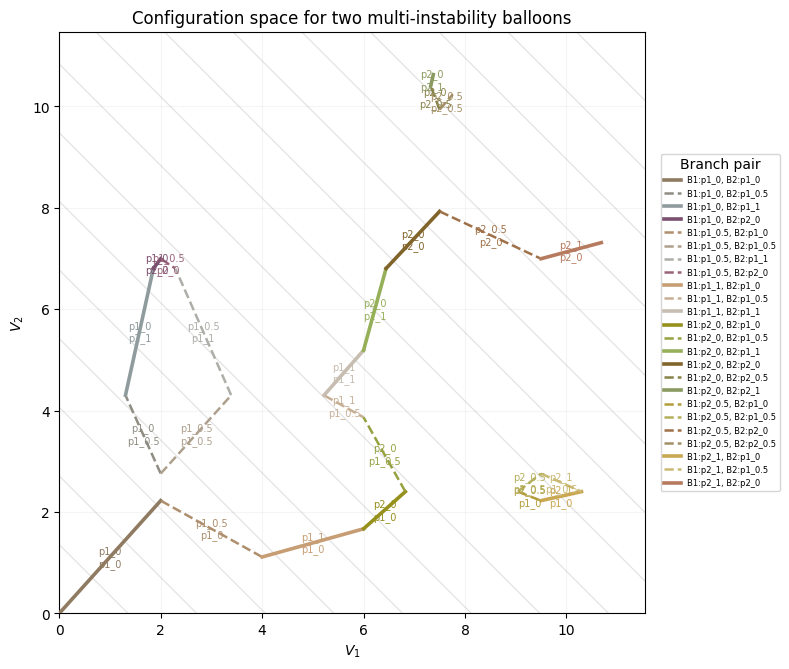

In [185]:
balloon1_multi = {
    "p1": {
        "a": 2.0,
        "b": 4.0,
        "g0": 1.0,
        "g_mid": -0.5,
        "g1": 0.25,
        "next_start": 6.0,
    },
    "p2": {
        "a": 1.5,
        "b": 3.5,
        "g0": 0.8,
        "g_mid": -0.35,
        "g1": 0.20,
        "next_start": None,
    },
}

balloon2_multi = {
    "p1": {
        "a": 2.4,
        "b": 4.3,
        "g0": 0.9,
        "g_mid": -0.45,
        "g1": 0.22,
        "next_start": 6.8,
    },
    "p2": {
        "a": 1.7,
        "b": 3.6,
        "g0": 0.75,
        "g_mid": -0.30,
        "g1": 0.18,
        "next_start": None,
    },
}

VT_values = np.linspace(0.0, 18.0, 4000)

branches = plot_configuration_space_multi_balloon(
    balloon1_multi,
    balloon2_multi,
    VT_values,
    VT_lines=True,
    show_labels=True,
)